# NSL-KDD Intrusion Detection System
## Anomaly Detection using Decision Trees and Neural Networks

Analysis of the NSL-KDD dataset using scikit-learn.  
Models: Decision Tree (entropy criterion) and MLP Neural Network.  
Dataset: https://www.unb.ca/cic/datasets/nsl.html

## 1. Introduction

IDS stands for Intrusion Detection System. It is a security technology that monitors. by examining network and system events, comparing them against predefined signatures (Signature-based detection) or behavioral patterns(Anomaly-based detection) , and generating alerts or taking preventive actions when potential intrusions or anomalies are detected.

 IDS can be deployed at various levels, including network-based IDS (NIDS) which examines network traffic, and host-based IDS (HIDS) focuses on individual systems or devices. The goal of an IDS is to enhance the overall security posture of a system or network by providing real-time monitoring and proactive threat detection.[5]
 
IDS Signature-based detection can't detect zero day attacks and problems , on the other hand it is possible for a behavioral IDS to identify novel attacks like zero day exploits, and NSL-KDD data is helping researchers using AI and to improve the performance of behavioral IDS[21]

### 1.1 About this document



Security analytics tools may analyse the data using a variety of techniques. These involve machine learning and statistical analysis in addition to conventional rules-based techniques.Security analytics helps by the data combined and examined from several sources to show and find correlations and abnormalities 
[6]

In our case we are trying to create a pipline to analyze and build an AI model simulating Anomaly-based detection systems using a data generated and used for Third International Knowledge Discovery and Data Mining Tools Competition KDD99, it is the most wildly used data set for the evaluation of anomaly detection methods [7], here, we are using the NSL-KDD version an inhanced version of the KDD99 where it had problems in redendancy, NSL-KDD stil has problem of not having public data sets
for network-based IDSs which does not simulate a real network traffic, but still helps research to build models for Anomaly-based detection systems, the gather data is about Denial of Service Attack (DoS), User to Root Attack (U2R), Remote to Local Attack (R2L), and probing attack [5]

In this documents using the NSL-KDD , speciafically Train++ and Test++ we are trying to dissect the mentionned data to understand first the data values , the meaning of features , which are related to PDU headers and captured data using different forensics tools. using statistics tools provided by python.

Using jupyter notebook, we going to prepare data to be ready and suitable for characterstics and requirement to train diffirent AI models , like Decision Tree and Neural networks, part of the preparation and cleasing data phase, we are going to explore the nature of data, like the types of values, the meaning of the values , the number of examples and features, and select the most important and meaningful data for training AI models, check duplicate values, and variations in within datasets, and other datasets used to evaluate and test the proficiency of the data which can cause problem to AI models like not generalizing well.

At the end, we will have a model trained using the dataset NSL-KDD able to detect if the traffic is of normal or abnormal behaviour.




## 2. Libraries and Initial Data Preparation

### 2.1 Libraries and Magics

* These imports cover a wide range of functionalities necessary for data analysis (numpy, pandas), visualization (pyplot, seaborn), scientific computing (Scipy: pearsonr), and machine learning tasks (sklearn)

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

#import warnings

#from sklearn.exceptions import ConvergenceWarning
#warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.preprocessing import MinMaxScaler

from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 
from sklearn.metrics import accuracy_score,precision_score, recall_score,f1_score, roc_auc_score

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

from matplotlib.ticker import FuncFormatter
from scipy.stats import pearsonr
from sklearn.preprocessing import LabelEncoder


In [2]:
%matplotlib inline 

### 2.2 Load the datasets

In [3]:
feature_columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate"
]
label_columns_raw = ["attack_type","difficulty_level"]
column_names = feature_columns + label_columns_raw

label_columns_extended = label_columns_raw+['test','anomaly']

bincols = ['land', 'logged_in', 'is_host_login',  'is_guest_login']
tercols = ['protocol_type']
multicols = ['service','flag']
catcols = bincols + tercols + multicols

#### 2.2.1.Load both datasets:(Train and Test):
- **KDDTrain+.txt** : The full NSL-KDD train set including attack-type labels and difficulty level in CSV format

- **KDDTest+.txt** : The full NSL-KDD test set including attack-type labels and difficulty level in CSV format

In [4]:
df_train_raw = pd.read_csv("KDDTrain+.txt")   # import train data from KDDTrain+.txt
df_test_raw = pd.read_csv("KDDTest+.txt")   # import test  data from KDDTest+.txt

In [5]:
display(df_train_raw) # 

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125967,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125968,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125969,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125970,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


In [6]:
display(df_test_raw)

,0,tcp,private,REJ,0.1,0.2,0.3,0.4,0.5,0.6,...,0.04.1,0.06.1,0.00.3,0.00.4,0.00.5,0.00.6,1.00.2,1.00.3,neptune,21
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,21
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,15
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11
4,0,tcp,http,SF,267,14515,0,0,0,0,...,1.00,0.00,0.01,0.03,0.01,0.0,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22538,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22539,0,tcp,http,SF,317,938,0,0,0,0,...,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22540,0,tcp,http,SF,54540,8314,0,0,0,2,...,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,back,15
22541,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,normal,21


- Both datasets has the same number of columns **43** 

#### 2.2.2 Setting appropriate column names (43)

- Columns are with no title, to help us understand and give context to values in the columns we set the names for 43 columns: 
- * With the help of dictionnary **dict()** function and the **zip()** method, and also the **rename** method of dataframes renaming the columns using list of **column_names**

In [7]:
df_train_raw.rename(columns=dict(zip(df_train_raw.columns, column_names)), inplace=True) # Rename columns of the training set
df_test_raw.rename(columns=dict(zip(df_test_raw.columns, column_names)), inplace=True) # Rename columns of the test set

In [8]:
display(df_train_raw) # Checking the training dataframe with new names 
display(df_test_raw)  # Checking the test dataframe with new names 


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125967,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125968,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125969,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125970,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,21
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,15
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11
4,0,tcp,http,SF,267,14515,0,0,0,0,...,1.00,0.00,0.01,0.03,0.01,0.0,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22538,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22539,0,tcp,http,SF,317,938,0,0,0,0,...,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22540,0,tcp,http,SF,54540,8314,0,0,0,2,...,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,back,15
22541,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,normal,21


#### 2.2.3 Adding test column in both datasets :
- This could help in the next part where we need to calculte the proportion of them to the whole dataset

In [9]:
df_train_raw["test"]=0 # Adding a new column "test" to df_train_raw and assigning value 0
df_test_raw["test"]=1 # Adding a new column "test" to df_test_raw and assigning value 1

display(df_train_raw, df_test_raw) # Displaying the modified DataFrames


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level,test
0,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,0
2,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0
3,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125967,0,tcp,private,S0,0,0,0,0,0,0,...,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20,0
125968,8,udp,private,SF,105,145,0,0,0,0,...,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21,0
125969,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18,0
125970,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20,0


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level,test
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21,1
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,21,1
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,15,1
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11,1
4,0,tcp,http,SF,267,14515,0,0,0,0,...,0.00,0.01,0.03,0.01,0.0,0.00,0.00,normal,21,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22538,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.06,0.01,0.01,0.01,0.0,0.00,0.00,normal,21,1
22539,0,tcp,http,SF,317,938,0,0,0,0,...,0.00,0.01,0.01,0.01,0.0,0.00,0.00,normal,21,1
22540,0,tcp,http,SF,54540,8314,0,0,0,2,...,0.00,0.00,0.00,0.00,0.0,0.07,0.07,back,15,1
22541,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.01,0.00,0.00,0.00,0.0,0.00,0.00,normal,21,1


* as shown in dataframe table the column was added now the **columns are 44** 

#### 2.2.4 Merging the two dataframes *train and test*: 
* The purpose of merging the data and test set is to explore and understand the features, inspecting missing values , or possibilty of outliers , in this I'm using the **concat()** method

In [10]:
# Concatenate df_train_raw and df_test_raw along rows to create a new DataFrame df_full_train_test
df_full_train_test=pd.concat([df_train_raw, df_test_raw], ignore_index =True) # `ignore_index=True` resets the index of the resulting DataFrame

df_full_train_test # Display the combined DataFrame

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level,test
0,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,0
2,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0
3,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148510,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.06,0.01,0.01,0.01,0.00,0.00,0.00,normal,21,1
148511,0,tcp,http,SF,317,938,0,0,0,0,...,0.00,0.01,0.01,0.01,0.00,0.00,0.00,normal,21,1
148512,0,tcp,http,SF,54540,8314,0,0,0,2,...,0.00,0.00,0.00,0.00,0.00,0.07,0.07,back,15,1
148513,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.01,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,1


* The number of the rows or examples as shown is **148515** which is correct , the combination between the two data set should be 

### 2.3 Initial Data Exploration

#### 2.3.1 Getting a Feel for the Data

#### 2.3.1.1 Display shape of Train, and test dataframes :

*The following lines shows* : 

* (125972 number of rows or examples, 44 number of features) Training dataframe

* (22543 number of rows or examples, 44 number of features) Test dataframe

* (148515 number of rows or examples, 44 number of features) the sum of both datasets 




In [11]:
df_train_raw.shape #Training Dataframe 

(125972, 44)

In [12]:
df_test_raw.shape  #Test Dataframe

(22543, 44)

In [13]:
df_full_train_test.shape #All dataset as Dataframe


(148515, 44)

#### 2.3.1.2 Calculating the proportion of test dataset and training dataset

In [14]:
# Initializing counters for the training and test sets
trainset_count = 0 
testset_count = 0

# Iterating through the 'test' column we added before in the DataFrame 'df_full_train_test'
for value in df_full_train_test['test']:
    # Checking if the value is 0, indicating it's part of the training set
    if value == 0:
        trainset_count += 1
    # Checking if the value is 1, indicating it's part of the test set
    elif value == 1:
        testset_count += 1
        
# Calculating the proportion of test set and training set in the DataFrame
testset_proportion = testset_count/df_full_train_test.shape[0]
trainset_proportion = trainset_count/df_full_train_test.shape[0]

# Printing the percentage of rows in the DataFrame that belong to the test set
print(f"Count in Test Dataframe: {testset_proportion:.2%}")
print(f"Count in Training Dataframe: {trainset_proportion:.2%}")

Count in Test Dataframe: 15.18%
Count in Training Dataframe: 84.82%


* The **Test dataset is aroud 15%** , and the **training dataset is around 85%** , this was already splited , given to us like this , which **close to the known norm** of splitting full datasets into **80% : training , 20%: test** [8] 

#### 2.3.1.3 Show that there is no null values in either dataframe :

* Trying to find null values in order to remove them or replace them using omission, or imputation techniques , in order to avoid the production of inaccurate or biased results [9]

* In our case we don't have any null values or No NaN (Not A Number) as shown below

In [15]:
#Checking for null values in the DataFrame 'df_full_train_test'
df_full_null_values=df_full_train_test.isnull().values.any().sum()

# Printing the number of columns with null value
print(f"The Number of Null Number (NaN) in the Dataframe is: {df_full_null_values}")


The Number of Null Number (NaN) in the Dataframe is: 0


#### 2.3.1.4 No duplicated rows in either the train or test sets : 
* we look for duplicated rows to avoid our analysis to be distorted or result in inaccurate results in AI models [10]
* In this case there no duplicated rows in both datasets as shown

In [16]:
dup_num_train_df = df_train_raw.duplicated().sum()
dup_num_test_df = df_test_raw.duplicated().sum()

print(f"Number of duplicated rows in Test Dataframe: {dup_num_test_df}")
print(f"Number of duplicated rows in Training Dataframe: {dup_num_train_df}")

Number of duplicated rows in Test Dataframe: 0
Number of duplicated rows in Training Dataframe: 0


#### 2.3.1.5 Drop attack types , difficulty_level, and test columns : 

* it is showing below the combined dataframe display the columns were dropped : 148515 rows × **41 columns**

In [17]:
# Make a copy for the Dataframe to test how dropping the columns affect 
df_full_train_test_2 = df_full_train_test.copy(deep=True)

In [18]:
#Specifying the columns to drop
drop_columns = ['attack_type','difficulty_level','test' ]

# Dropping the columns using drop , and inplace=True
df_full_train_test_2.drop(columns=drop_columns, axis=1, inplace=True)


In [19]:
#Showing the effect of inplace = True, showing dataframe after dropping th three columns  
display(df_full_train_test_2)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,udp,other,SF,146,0,0,0,0,0,...,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00
1,0,tcp,private,S0,0,0,0,0,0,0,...,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00
2,0,tcp,http,SF,232,8153,0,0,0,0,...,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01
3,0,tcp,http,SF,199,420,0,0,0,0,...,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0,tcp,private,REJ,0,0,0,0,0,0,...,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148510,0,tcp,smtp,SF,794,333,0,0,0,0,...,100,141,0.72,0.06,0.01,0.01,0.01,0.00,0.00,0.00
148511,0,tcp,http,SF,317,938,0,0,0,0,...,197,255,1.00,0.00,0.01,0.01,0.01,0.00,0.00,0.00
148512,0,tcp,http,SF,54540,8314,0,0,0,2,...,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.07,0.07
148513,0,udp,domain_u,SF,42,42,0,0,0,0,...,255,252,0.99,0.01,0.00,0.00,0.00,0.00,0.00,0.00


* **2.3.1.5.2 Duplicated rows after dropping 'attack_type','difficulty_level','test' in combined**:



In [20]:
dup_num_full_df = df_full_train_test_2.duplicated().sum() # finding number of duplicated rows in combined dataset
print(f"Number of duplicated rows in Full Dataframe: {dup_num_full_df}") # showing the number 

Number of duplicated rows in Full Dataframe: 727


* **2.3.1.5.2 Drop 'attack types' , 'anmaly', and 'test' columns in each dataframe :**

In [21]:
df_train_raw_2=df_train_raw.copy()
df_test_raw_2=df_test_raw.copy()

drop_columns = ['attack_type','difficulty_level','test' ]
drop = df_train_raw_2.drop(columns=drop_columns, axis=1, inplace=True)
drop = df_test_raw_2.drop(columns=drop_columns, axis=1, inplace=True)

display(df_train_raw_2, df_test_raw_2)




,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,udp,other,SF,146,0,0,0,0,0,...,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00
1,0,tcp,private,S0,0,0,0,0,0,0,...,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00
2,0,tcp,http,SF,232,8153,0,0,0,0,...,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01
3,0,tcp,http,SF,199,420,0,0,0,0,...,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0,tcp,private,REJ,0,0,0,0,0,0,...,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125967,0,tcp,private,S0,0,0,0,0,0,0,...,255,25,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00
125968,8,udp,private,SF,105,145,0,0,0,0,...,255,244,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00
125969,0,tcp,smtp,SF,2231,384,0,0,0,0,...,255,30,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00
125970,0,tcp,klogin,S0,0,0,0,0,0,0,...,255,8,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,tcp,private,REJ,0,0,0,0,0,0,...,255,1,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,134,86,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,3,57,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,29,86,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71
4,0,tcp,http,SF,267,14515,0,0,0,0,...,155,255,1.00,0.00,0.01,0.03,0.01,0.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22538,0,tcp,smtp,SF,794,333,0,0,0,0,...,100,141,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00
22539,0,tcp,http,SF,317,938,0,0,0,0,...,197,255,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00
22540,0,tcp,http,SF,54540,8314,0,0,0,2,...,255,255,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07
22541,0,udp,domain_u,SF,42,42,0,0,0,0,...,255,252,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00


* **2.3.1.5.2 Duplicated rows after dropping 'attack_type','difficulty_level','test' in each dataframe:**

In [22]:
dup_train_raw_2= df_train_raw_2.duplicated().sum() #finding number of duplicated rows in training dataset
dup_test_raw_2 = df_test_raw_2.duplicated().sum() #finding number of duplicated rows in test dataset

print(f"Number of duplicated rows in Train Dataframe: {dup_train_raw_2}") # showing the number in training
print(f"Number of duplicated rows in  Test Dataframe: {dup_test_raw_2}") # showing the number in test

Number of duplicated rows in Train Dataframe: 16
Number of duplicated rows in  Test Dataframe: 57


* Duplicate rows were identified after dropping the label columns. Some duplicated feature vectors may have different label assignments, which can introduce noise during training and affect model generalisation.

In [23]:
dup_train_raw_3 = df_train_raw_2.copy()
dup_test_raw_3 = df_test_raw_2.copy()

# Identify rows with the same values across all features
duplicates_all_features = dup_train_raw_3[dup_train_raw_3.duplicated(keep=False)]

# Check if 'attack_type' column exists in duplicates_all_features
if 'attack_type' in duplicates_all_features.columns:
    # Identify rows with different classifiers
    inconsistent_classifiers = duplicates_all_features[duplicates_all_features['attack_type'].duplicated(keep=False)]

    # Display the rows with different classifiers
    print("Rows with the same values but different classifiers:")
    print(inconsistent_classifiers)
else:
    print("Column 'attack_type' not found in duplicates_all_features.")



Column 'attack_type' not found in duplicates_all_features.


#### Comment  : 

 * **_The portions of training dataset and test dataset here follow almost one of the common norms of 80% and 20%  respectively , which is agood practice , using other known practices[11] the data fully has 148 515 columns 44 now after adding the test column, this amount is amount of data is a huge struggle to go through manually , this is why tools like this would help explore the characteristics of it easly , like for instance finding that there are 16 identical rows in training dataset and 56 in test dataset , some the duplicated rows has identcical values but different label column values,  which could lead the model not being able to generalize well, or in another words lead overfitting by learning from this noise in the data, and these issues needs to be addressed [12]_** 

#### 2.3.2 Merging test and training data

#### 2.3.2.1 Extend the training and test dataframes with a new column 'test'

In [24]:
df_train_raw['test'] = 0
df_test_raw['test'] = 1


#### 2.3.2.2 Merge both training and test dataframes together using concat ()

In [25]:
# Concatenate (combine) the training and test DataFrames vertically and reset index using Contact() method
df_all_raw = pd.concat([df_train_raw, df_test_raw], ignore_index =True)

# Display the combined DataFrame
display(df_all_raw) 

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level,test
0,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,0
2,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0
3,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148510,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.06,0.01,0.01,0.01,0.00,0.00,0.00,normal,21,1
148511,0,tcp,http,SF,317,938,0,0,0,0,...,0.00,0.01,0.01,0.01,0.00,0.00,0.00,normal,21,1
148512,0,tcp,http,SF,54540,8314,0,0,0,2,...,0.00,0.00,0.00,0.00,0.00,0.07,0.07,back,15,1
148513,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.01,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,1


#### * Checking data type for all datasets 

In [26]:
print(df_full_train_test.dtypes)

duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

* ***Here is shown that there is categorical values and numerical values , this should be taken into account before training the model*** 

#### 2.3.3 Difficulty Levels

####  2.3.3.1 Normalized value count "relative frequency " for "difficulty level" 

In [27]:
normalized_counts_train = df_train_raw['difficulty_level'].value_counts(normalize=True).sort_index()
normalized_counts_test = df_test_raw['difficulty_level'].value_counts(normalize=True).sort_index()

formatted_nc_train = normalized_counts_train.map(lambda x: f"{x:.2%}")
formatted_nc_test = normalized_counts_test.map(lambda x: f"{x:.2%}")

print(f"Proportion of difficulty level values in training dataset: \n{formatted_nc_train}\n")
print(f"Proportion of difficulty level values in test dataset: \n{formatted_nc_test}\n")


Proportion of difficulty level values in training dataset: 
difficulty_level
0      0.05%
1      0.05%
2      0.04%
3      0.05%
4      0.06%
5      0.06%
6      0.08%
7      0.09%
8      0.08%
9      0.15%
10     0.20%
11     0.51%
12     0.58%
13     0.36%
14     0.54%
15     3.17%
16     1.90%
17     2.44%
18    16.41%
19     8.16%
20    15.35%
21    49.66%
Name: proportion, dtype: object

Proportion of difficulty level values in test dataset: 
difficulty_level
0      0.55%
1      0.39%
2      0.24%
3      0.51%
4      0.45%
5      0.46%
6      0.70%
7      1.10%
8      0.58%
9      0.47%
10     0.87%
11     2.04%
12     2.16%
13     2.30%
14     3.26%
15     5.22%
16     3.02%
17     5.18%
18    13.16%
19     3.95%
20     5.96%
21    47.43%
Name: proportion, dtype: object



* **_The proportions shown above of the levels from 21 to 17 has most of the distribution in both datasets which could suggest that the data is  skewed here_** 

 #### 2.3.3.2 Visualization of the counts for the difficulty levels: Training and Test 

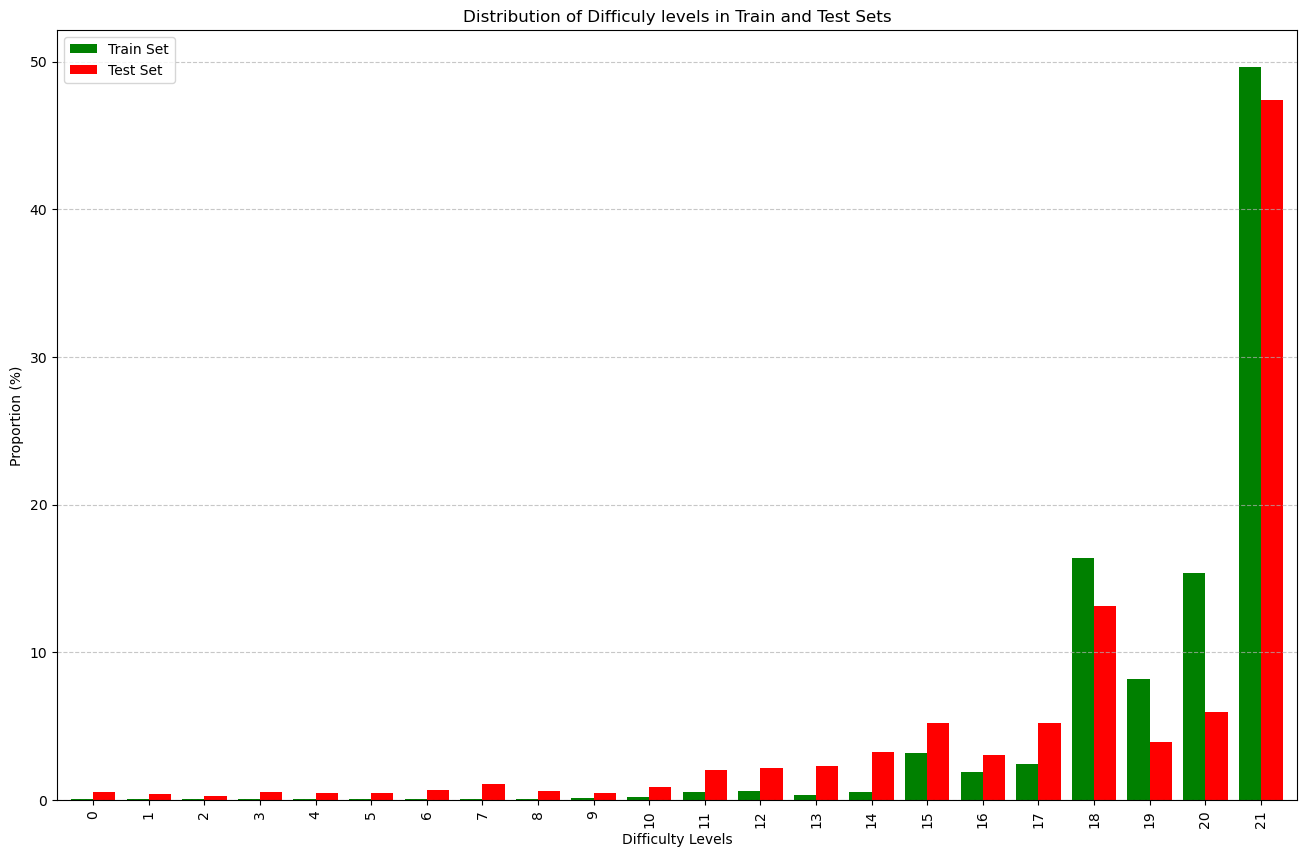

In [28]:
# Multiply the values by 100 to convert them to percentages
combined_defl_dist = pd.DataFrame({
    'Train Set': normalized_counts_train * 100,
    'Test Set': normalized_counts_test * 100
}).sort_index()

# Plotting
fig, ax = plt.subplots(figsize=(16, 10))

# Bar plot
combined_defl_dist.plot(kind='bar', ax=ax, width=0.8, color=['green', 'red'])

# Set labels and title
ax.set_xlabel('Difficulty Levels')
ax.set_ylabel('Proportion (%)')  
ax.set_title('Distribution of Difficuly levels in Train and Test Sets')

# Add grid lines for better visibility
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


#### 2.3.3.4 Comment :

The numbers and visualizations presented before show a skewness in both datasets higher a bit training dataset than test dataset which indicates a consistant inbalance in the data, the difficuly levels of 21 20 19 and 18 have a high portion of the distribution with more than 70%  , this could lead to the trained model to be biased , this sould held into account too , by using techniques such as resampling [3]  

#### 2.3.4 Attack Types

#### 2.3.4.1 Proportions of the attack types in the test and train datasets

In [29]:
# Count occurrences of each attack type to the total of the all attack types
train_attack_norm = df_train_raw['attack_type'].value_counts(normalize=True)
test_attack_norm = df_test_raw['attack_type'].value_counts(normalize=True)


# Display or use the results as needed
print("Training Attack Proportions:")
print("=============================")
print(train_attack_norm)

print("\nTest Attack Proportions:")
print("=============================")
print(test_attack_norm)


Training Attack Proportions:
attack_type
normal             0.534579
neptune            0.327168
satan              0.028840
ipsweep            0.028570
portsweep          0.023267
smurf              0.021005
nmap               0.011852
back               0.007589
teardrop           0.007081
warezclient        0.007065
pod                0.001596
guess_passwd       0.000421
buffer_overflow    0.000238
warezmaster        0.000159
land               0.000143
imap               0.000087
rootkit            0.000079
loadmodule         0.000071
ftp_write          0.000064
multihop           0.000056
phf                0.000032
perl               0.000024
spy                0.000016
Name: proportion, dtype: float64

Test Attack Proportions:
attack_type
normal             0.430777
neptune            0.206539
guess_passwd       0.054607
mscan              0.044182
warezmaster        0.041876
apache2            0.032693
satan              0.032604
processtable       0.030386
smurf              0

In [30]:
# Compare the proportions
proportions_compare = train_attack_norm.equals(test_attack_norm)


print("Is the proportion of attack types the same in both datasets :", proportions_compare)

Is the proportion of attack types the same in both datasets : False


* As it is shown the proprtions of attack types(feature level column) in training dataset is **different** from the test dataset

#### 2.3.4.2 Dataframe showing attack types : Count and Normalized value for the training set and the test set.

In [31]:


#Extract unique attack types from both datasets
unique_attack_types = set(df_train_raw['attack_type'].unique()) | set(df_test_raw['attack_type'].unique())


#print (len(df_test_raw['attack_type'].unique()))
#print (len(df_train_raw['attack_type'].unique()))

#Count occurrences of each attack type in the training and test sets
train_attack_counts = df_train_raw['attack_type'].value_counts()
test_attack_counts = df_train_raw['attack_type'].value_counts()

# Step 3: Fill missing attack types with zero counts
for attack_type in unique_attack_types:
    if attack_type not in train_attack_counts.index:
        train_attack_counts[attack_type] = 0
    if attack_type not in test_attack_counts.index:
        test_attack_counts[attack_type] = 0


# Step 5: Create a DataFrame
data = {
    'Training Count': train_attack_counts,
    'Training Normalized': train_attack_norm ,
    'Test Count': test_attack_counts,
    'Test Normalized': train_attack_norm 
}

result_df = pd.DataFrame(data)

# Display or use the resulting DataFrame
print(result_df)


                 Training Count  Training Normalized  Test Count  \
attack_type                                                        
apache2                       0                  NaN           0   
back                        956             0.007589         956   
buffer_overflow              30             0.000238          30   
ftp_write                     8             0.000064           8   
guess_passwd                 53             0.000421          53   
httptunnel                    0                  NaN           0   
imap                         11             0.000087          11   
ipsweep                    3599             0.028570        3599   
land                         18             0.000143          18   
loadmodule                    9             0.000071           9   
mailbomb                      0                  NaN           0   
mscan                         0                  NaN           0   
multihop                      7             0.00

#### 2.3.4.3 Visualization of the proportions (attack types in training and test datasets)

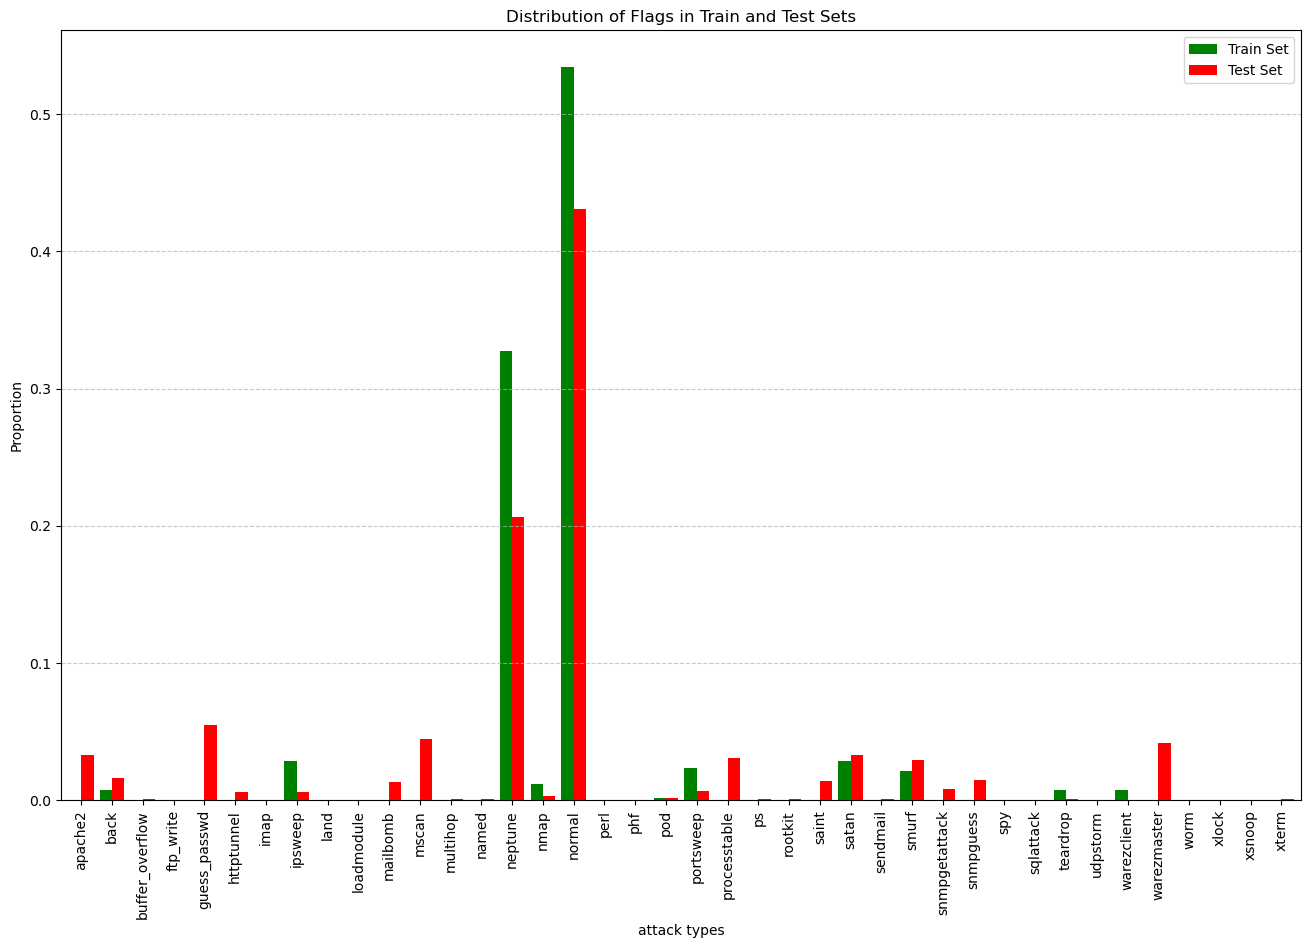

In [32]:
#train_attack_norm = df_train_raw['attack_type'].value_counts(normalize=True)
#test_attack_norm = df_train_raw['attack_type'].value_counts(normalize=True)

# Combine the distributions into a single DataFrame for easier plotting
combined_attack_dist = pd.DataFrame({
    'Train Set': train_attack_norm,
    'Test Set': test_attack_norm
}).sort_index()

# Plotting
fig, ax = plt.subplots(figsize=(16, 10))

# Bar plot
combined_attack_dist.plot(kind='bar', ax=ax, width = 0.8, color=['green', 'red'])

# Set labels and title
ax.set_xlabel('attack types')
ax.set_ylabel('Proportion')
ax.set_title('Distribution of Flags in Train and Test Sets')

# Add grid lines for better visibility
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

#### 2.3.4.4 Attack types presence both datasets 

In [33]:
# To get unique attack types in the train and test datasets
train_attack_types = set(df_train_raw['attack_type'].unique())
test_attack_types = set(df_test_raw['attack_type'].unique())

# To check if all attack types in the train dataset are present in the test dataset
all_in_test = all(attack_type in test_attack_types for attack_type in train_attack_types)

# To check if all attack types in the test dataset are present in the train dataset
all_in_train = all(attack_type in train_attack_types for attack_type in test_attack_types)

# to find attack types in the train dataset that are not in the test dataset
types_only_in_train = train_attack_types - test_attack_types

# To find attack types in the test dataset that are not in the train dataset
types_only_in_test = test_attack_types - train_attack_types


# Print the results
print(f"All attack types in train dataset are present in test dataset: {all_in_test}")
print("--------------------------------------------------------------------------------------------------------------------")
print(f"All attack types in test dataset are present in train dataset: {all_in_train}")
print("====================================================================================================================")


# List the uniques types for each datasets compared to eachother 
print(f"Values only in the train dataset: {types_only_in_train}")
print("--------------------------------------------------------------------------------------------------------------------")
print(f"Values only in the test dataset: {types_only_in_test}")



All attack types in train dataset are present in test dataset: False
--------------------------------------------------------------------------------------------------------------------
All attack types in test dataset are present in train dataset: False
Values only in the train dataset: {'warezclient', 'spy'}
--------------------------------------------------------------------------------------------------------------------
Values only in the test dataset: {'xterm', 'worm', 'sqlattack', 'mscan', 'named', 'xsnoop', 'httptunnel', 'apache2', 'snmpguess', 'saint', 'ps', 'udpstorm', 'sendmail', 'mailbomb', 'xlock', 'snmpgetattack', 'processtable'}


#### 2.3.4.5 Comment on what you have found:

* By inspecting the plotting and the list of types of attacks existing in both the training dataset and test dataset , or in just one of them only, it shows first that there is some variance , but on another hand most of proportions in both datasets seems to fall under neptune and normal , this could lead into skewness of data, but if we consider that this is a model trained based on normal or abnormal behavior , which means other than than normal value everything else is taken as anomaly , than in this case the data may somehow seem suitable to some extent to use it for training but not as it should be, but after performing encoding and rescaling it could be useful for training a model.

#### 2.3.5 Normal versus Abnormal Behaviour 

#### 2.3.5.1 Adding column 'anomaly' to train and test datasets 

In [34]:
#Adding anomaly column with value
df_train_raw['anomaly'] = df_train_raw['attack_type'].apply(lambda x: 0 if x == 'normal' else 1) 
df_test_raw['anomaly'] = df_test_raw['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)

#Full dataset
df_full_train_test['anomaly'] = df_full_train_test['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)  
display(df_full_train_test)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level,test,anomaly
0,0,udp,other,SF,146,0,0,0,0,0,...,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0,0
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,0,1
2,0,tcp,http,SF,232,8153,0,0,0,0,...,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0,0
3,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0,0
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148510,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.01,0.01,0.01,0.00,0.00,0.00,normal,21,1,0
148511,0,tcp,http,SF,317,938,0,0,0,0,...,0.01,0.01,0.01,0.00,0.00,0.00,normal,21,1,0
148512,0,tcp,http,SF,54540,8314,0,0,0,2,...,0.00,0.00,0.00,0.00,0.07,0.07,back,15,1,1
148513,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,1,0


#### 2.3.5.2 Plotting the anomalies and non-anomalies :

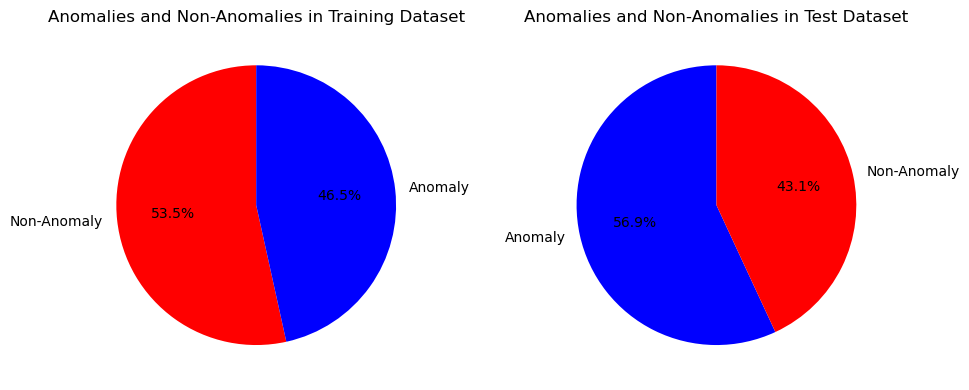

In [35]:
num_ana_nonana_train = df_train_raw['anomaly'].value_counts(normalize=True)
num_ana_nonana_test = df_test_raw['anomaly'].value_counts(normalize=True)

label_mapped = {0: "Non-Anomaly", 1: "Anomaly"}
mapped_labels_train = num_ana_nonana_train.index.map(label_mapped)
mapped_labels_test = num_ana_nonana_test.index.map(label_mapped)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Plot for training dataset
axes[0].pie(num_ana_nonana_train.values, labels=mapped_labels_train, autopct='%1.1f%%', startangle=90, colors=['red','blue'])
axes[0].set_title('Anomalies and Non-Anomalies in Training Dataset')

# Plot for test dataset
axes[1].pie(num_ana_nonana_test.values, labels=mapped_labels_test, autopct='%1.1f%%', startangle=90, colors=['blue', 'red'])
axes[1].set_title('Anomalies and Non-Anomalies in Test Dataset')

# Adjust layout to prevent overlapping
plt.tight_layout()
#plt.legend()

# Show the plots
plt.show()

#### 2.5.3.3 Comment :

* The training dataset has a relatively balanced distribution between anomalies and non-anomalies, which is generally beneficial for model training, but if anomalies are significantly underrepresented, the model could have a problem in generalizing well to unseen anomalies.

* The test dataset introduces a higher proportion of anomalies (56.9%), which can be useful for evaluating how well the model generalizes to situations it has not seen during training. compared to the real-world scenario, the model evaluation may not accurately reflect its performance in practical applications. 

* Logically the in the network traffic , the proprtion of anomalies would not reach more than 50% in most cases, and for this specific data, McHugh mentioned a problem in the dataset stating that may not be a perfect representative of existing real networks, because of the lack of public data sets for network-based IDSs [2]




### 2.4 About the Features

#### 2.4.1 Association of Service Data and Anomalous-ness

#### 2.4.1.1 Services corrolation with protocol types in full dataset :

In [36]:
service_proto_full = df_full_train_test.pivot_table(index='service', columns='protocol_type', aggfunc='size', fill_value=0)
pd.set_option('display.max_rows', None)
display(service_proto_full)
service_proto_full.info()

protocol_type,icmp,tcp,udp
service,,,
IRC,0,200,0
X11,0,88,0
Z39_50,0,907,0
aol,0,2,0
auth,0,1022,0
bgp,0,756,0
courier,0,774,0
csnet_ns,0,579,0
ctf,0,604,0


<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, IRC to whois
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   icmp    70 non-null     int64
 1   tcp     70 non-null     int64
 2   udp     70 non-null     int64
dtypes: int64(3)
memory usage: 2.2+ KB


In [37]:
# Selecting rows where more than one value is non-zero across columns
Services_more_types = service_proto_full[(service_proto_full.iloc[:, 1:] != 0).sum(axis=1) > 1]

Services_more_types

protocol_type,icmp,tcp,udp
service,,,
other,0,2536,2661
private,0,21792,4834


* There are two services which have more than one protocol type : **other, and private** 

#####  2.4.1.2 Visualize value count , normalized count of services :  

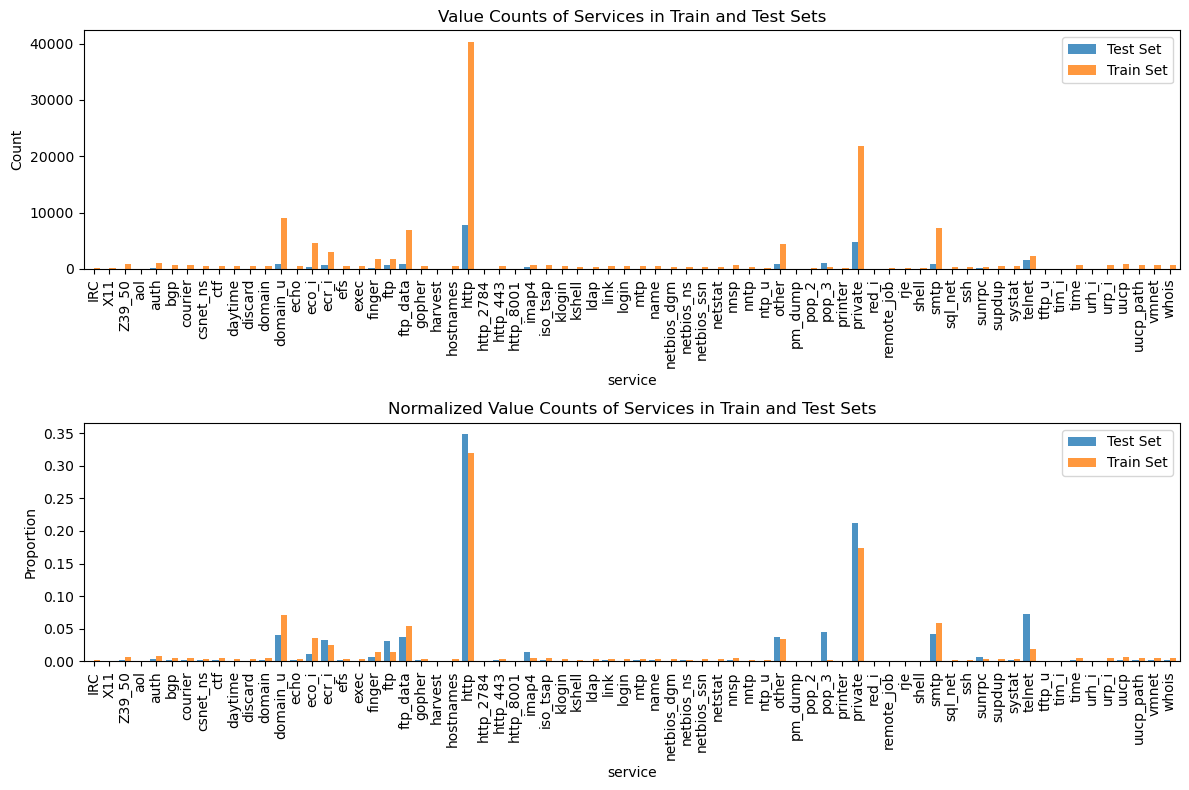

In [38]:

df_combined = pd.concat([df_train_raw, df_test_raw], keys=['Train Set', 'Test Set'])

# Calculate value counts and normalized value counts for each service in each dataset
value_counts = df_combined['service'].groupby(df_combined.index.get_level_values(0)).value_counts()
normalized_counts = df_combined['service'].groupby(df_combined.index.get_level_values(0)).value_counts(normalize=True)

# Create a DataFrame with value counts and normalized counts
df_counts = pd.DataFrame({'Value Counts': value_counts, 'Normalized Counts': normalized_counts})

# Reshape the DataFrame for better visualization
df_counts = df_counts.unstack(level=0)

# Plotting
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

# Bar plot for Value Counts
df_counts['Value Counts'].plot(kind='bar', ax=axes[0], width=0.8, alpha=0.8)
axes[0].set_ylabel('Count')
axes[0].set_title('Value Counts of Services in Train and Test Sets')

# Bar plot for Normalized Counts
df_counts['Normalized Counts'].plot(kind='bar', ax=axes[1], width=0.8, alpha=0.8)
axes[1].set_ylabel('Proportion')
axes[1].set_title('Normalized Value Counts of Services in Train and Test Sets')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [39]:
pd.reset_option('display.max_rows')
# Creating a DataFrame with all four columns
df_all_counts = pd.concat([value_counts, normalized_counts], axis=1, keys=['Counts', 'Normalized Counts'])

df_all_counts

Counts  Normalized Counts
          service                             
Test Set  http         7853           0.348356
          private      4773           0.211729
          telnet       1626           0.072129
          pop_3        1019           0.045203
          smtp          934           0.041432
...                     ...                ...
Train Set tftp_u          3           0.000024
          http_8001       2           0.000016
          harvest         2           0.000016
          aol             2           0.000016
          http_2784       1           0.000008

[134 rows x 2 columns]

* __The plotting and the table shows that the most the distribution of services is around services like http and services  in both datasets training and test__ 

* **2.4.1.3 Which services are not present in which datasets :**

In [40]:
unique_services_train_s = set(df_train_raw['service'].unique())
unique_services_test_s = set(df_test_raw['service'].unique())

# Find services not present in the train set
services_not_in_train = unique_services_test_s - unique_services_train_s

# Find services not present in the test set
services_not_in_test = unique_services_train_s - unique_services_test_s

# Display the results
print("Services not present in the Train Set:", services_not_in_train)
print("\nServices not present in the Test Set:", services_not_in_test)



Services not present in the Train Set: set()

Services not present in the Test Set: {'harvest', 'aol', 'http_8001', 'red_i', 'urh_i', 'http_2784'}


#### 2.4.1.4 Services with less than 0.05% normalized counts in the Test and training dataset:

In [41]:
service_test=df_test_raw["service"].value_counts(normalize=True)

# Identify services with less than 0.05% normalized counts
small_fraction_services_test = service_test[service_test < 0.0005]

# Display the identified services
print("Services with less than 0.05% normalized counts in the Test dataset:")
print(small_fraction_services_test*100)

Services with less than 0.05% normalized counts in the Test dataset:
service
printer    0.048796
ntp_u      0.044360
rje        0.035488
tim_i      0.026616
tftp_u     0.004436
Name: proportion, dtype: float64


In [42]:
service_train=df_train_raw["service"].value_counts(normalize=True)

# Identify services with less than 0.05% normalized counts
small_fraction_services_train= service_train[service_train < 0.0005]

# Display the identified services
print("Services with less than 0.05% normalized counts in the Train dataset:")
print(small_fraction_services_train*100)

Services with less than 0.05% normalized counts in the Train dataset:
service
urh_i        0.007938
tim_i        0.006351
red_i        0.006351
pm_dump      0.003969
tftp_u       0.002381
http_8001    0.001588
aol          0.001588
harvest      0.001588
http_2784    0.000794
Name: proportion, dtype: float64


* **This could suggest that these services have a low occurence and it be anomalies or they are less used, it could be a challange for the model generalization**

#### 2.4.1.5 Calculate the Pearson correlation coefficient by service type 

In [43]:
# Fill missing services in either dataset with 0
all_services = set(service_train.index) | set(service_test.index)
service_train = service_train.reindex(all_services, fill_value=0)
service_test = service_test.reindex(all_services, fill_value=0)

# Calculate Pearson correlation coefficient for the test dataset
correlation_coefficient, p_value = pearsonr(service_train , service_test)

print(f"Pearson Correlation Coefficient for Dataset: {correlation_coefficient}")
print(f"P-value: {p_value}")

# Check if the correlation is considered high
if abs(correlation_coefficient) >= 0.7:
    print("The correlation is considered high.")
else:
    print("The correlation is not considered high.")

Pearson Correlation Coefficient for Dataset: 0.9728328258471334
P-value: 6.113384107880689e-45
The correlation is considered high.


* **Pearson correlation closer to 1 shows a strong correlation between services in the training dataset and test dataset**

#### 2.4.1.6 Produce a bar plot showing, among the anomalies, the proportion of each service

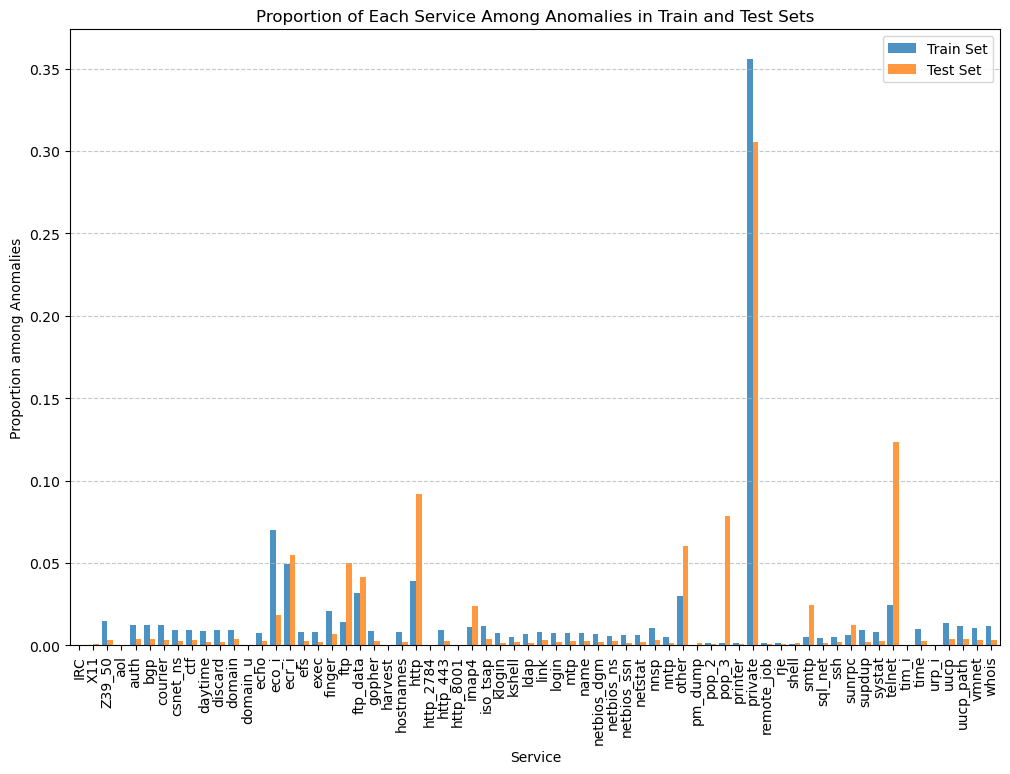

In [44]:
# Filter anomalies in train and test datasets
anomalies_train_ = df_train_raw[df_train_raw['anomaly'] == 1]
anomalies_test_ = df_test_raw[df_test_raw['anomaly'] == 1]

# Calculate the proportion of each service among anomalies
proportion_train_ = anomalies_train_['service'].value_counts(normalize=True)
proportion_test_ = anomalies_test_['service'].value_counts(normalize=True)

# Create a DataFrame for plotting
df_plot = pd.DataFrame({'Train Set': proportion_train_, 'Test Set': proportion_test_})

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Bar plot
df_plot.plot(kind='bar', ax=ax, width=0.8, alpha=0.8)

# Set labels and title
ax.set_xlabel('Service')
ax.set_ylabel('Proportion among Anomalies')
ax.set_title('Proportion of Each Service Among Anomalies in Train and Test Sets')

# Add legend
ax.legend()

# Add grid lines for better visibility
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


* **This plot shows that a slim variance between the test and training data set for the number of services in anomalies , where most anomolies is in private and telnet , this also could be a challenge for the model generalization**


#### 2.4.1.7 Pearson correlation coefficient between the train and test sets for the distribution of services within the anomalies.

In [45]:
counts_df_test_sa = df_test_raw.groupby(['service', 'anomaly']).size().reset_index(name='counts_Tst')
counts_df_train_sa = df_train_raw.groupby(['service', 'anomaly']).size().reset_index(name='counts_Tr')

combined_counts_df = pd.merge(counts_df_test_sa, counts_df_train_sa, 
                              on=['service', 'anomaly'], 
                              suffixes=('_Tst', '_Tr'), 
                              how='outer').fillna(0)

anomalies_df = combined_counts_df[combined_counts_df['anomaly'] == 1]

# Calculate Pearson correlation coefficient
correlation_coefficient_srv_ano, _ = pearsonr(anomalies_df['counts_Tst'], anomalies_df['counts_Tr'])

print(f"Pearson Correlation Coefficient: {correlation_coefficient_srv_ano}")

Pearson Correlation Coefficient: 0.8854993327522106


* **It has a strong correlation between the two datasets in term services anomalies , this could indicate Feature Redundancy**

#### 2.4.1.8 produce a scatterplot. The points plotted will be services

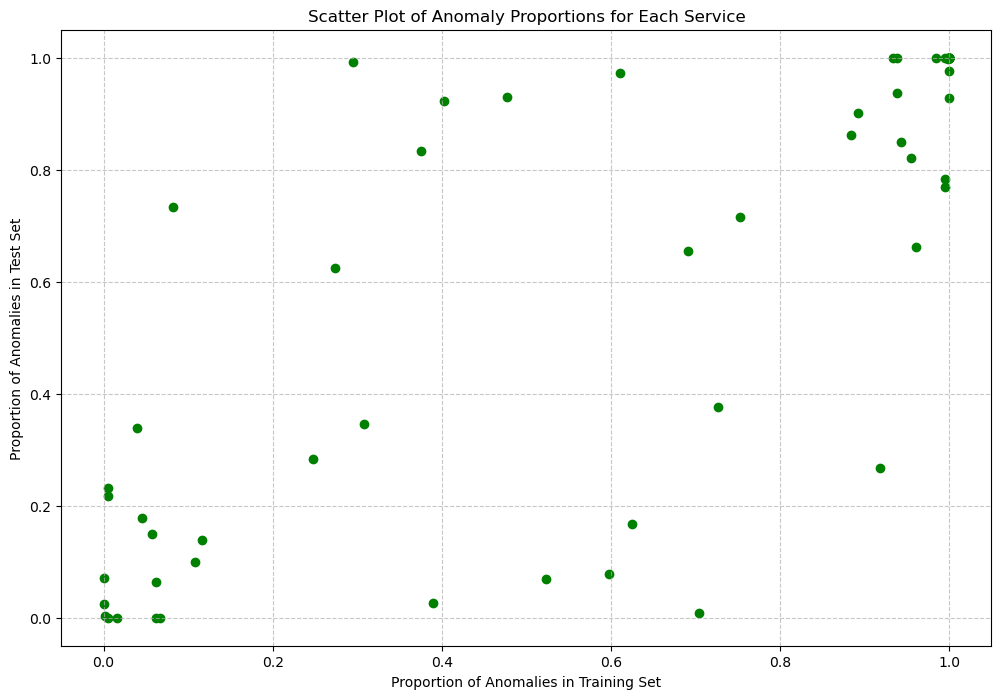

In [46]:
# Calculate proportions for each service
combined_counts_df['Proportion_Tr'] = combined_counts_df['counts_Tr'] / combined_counts_df.groupby('service')['counts_Tr'].transform('sum')
combined_counts_df['Proportion_Tst'] = combined_counts_df['counts_Tst'] / combined_counts_df.groupby('service')['counts_Tst'].transform('sum')

# Plotting scatter plot for each service
fig, ax = plt.subplots(figsize=(12, 8))

# Iterate over unique services and plot scatter points
for service in combined_counts_df['service'].unique():
    service_data = combined_counts_df[combined_counts_df['service'] == service]
    ax.scatter(service_data['Proportion_Tr'], service_data['Proportion_Tst'], label=service, color = 'green')

# Set labels and title
ax.set_xlabel('Proportion of Anomalies in Training Set')
ax.set_ylabel('Proportion of Anomalies in Test Set')
ax.set_title('Scatter Plot of Anomaly Proportions for Each Service')

#grid lines
ax.grid(axis='both', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

### 2.4.1.9 Comment: 

* Overall the data representation shows a little variance around services in relation to anomalies , but the proportion is high in some services , which could make it a challange for the model to generlize well as desired and to classify well new anomalies 

#### 2.4.2 Flag Data

#### 2.4.2.1 Distributions of flags across each of the train and test sets

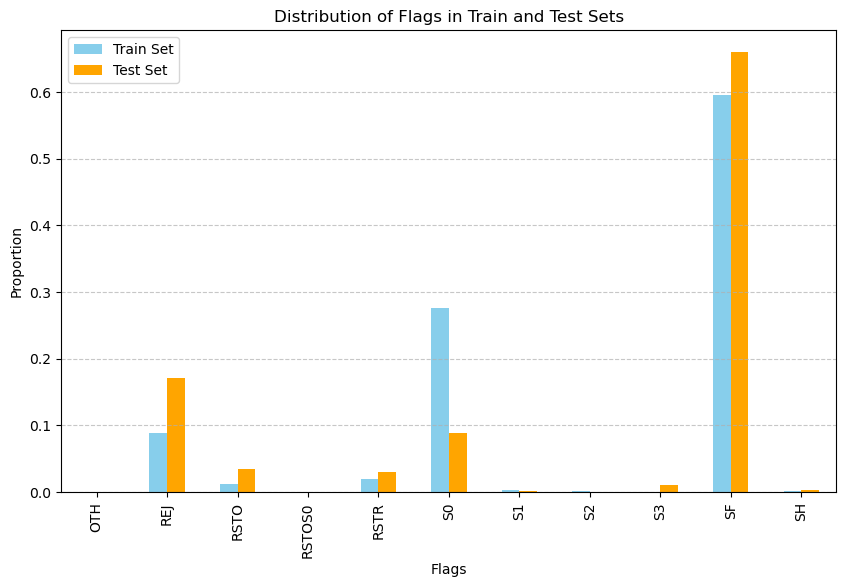

In [47]:

# Calculate flag distributions for the train set
train_flag_dist= df_train_raw['flag'].value_counts(normalize=True)

# Calculate flag distributions for the test set
test_flag_dist = df_test_raw['flag'].value_counts(normalize=True)

# Combine the distributions into a single DataFrame for easier plotting
combined_flag_dist = pd.DataFrame({
    'Train Set': train_flag_dist,
    'Test Set': test_flag_dist
}).sort_index()

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Bar plot
combined_flag_dist.plot(kind='bar', ax=ax, color=['skyblue', 'orange'])

# Set labels and title
ax.set_xlabel('Flags')
ax.set_ylabel('Proportion')
ax.set_title('Distribution of Flags in Train and Test Sets')

# Add grid lines for better visibility
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


  #### 2.4.2.2 Proportion of flag that are anomalies :

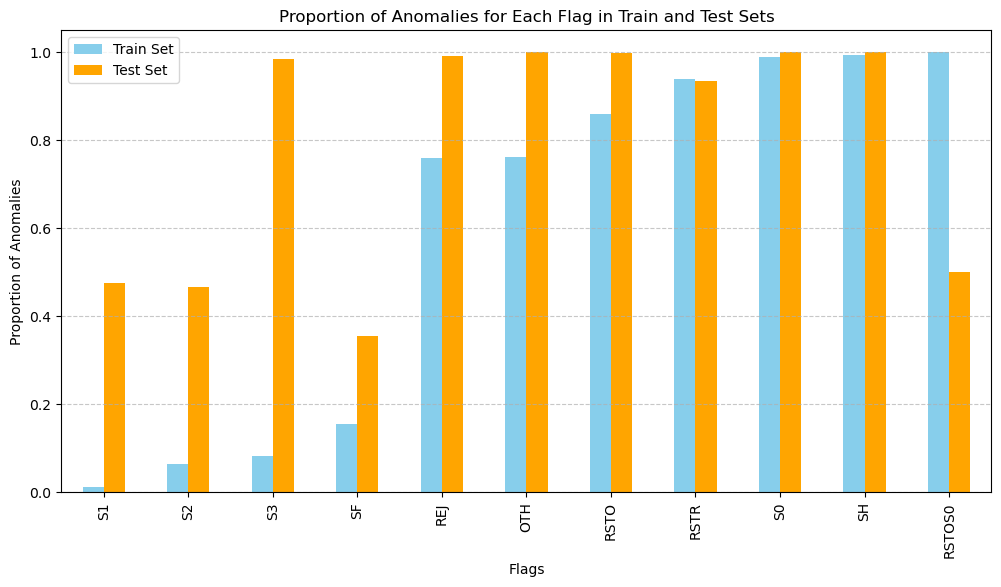

In [48]:


# Calculate the proportion of anomalies for each flag in the train set
train_flag_anomaly_proportion = df_train_raw.groupby('flag')['anomaly'].mean()

# Calculate the proportion of anomalies for each flag in the test set
test_flag_anomaly_proportion = df_test_raw.groupby('flag')['anomaly'].mean()

# Combine the proportions into a single DataFrame for easier plotting
combined_flag_anomaly_proportion = pd.DataFrame({
    'Train Set': train_flag_anomaly_proportion,
    'Test Set': test_flag_anomaly_proportion
}).sort_values(by='Train Set')  # Sort by the proportion in the train set for better visualization

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Bar plot
combined_flag_anomaly_proportion.plot(kind='bar', ax=ax, color=['skyblue', 'orange'])

# Set labels and title
ax.set_xlabel('Flags')
ax.set_ylabel('Proportion of Anomalies')
ax.set_title('Proportion of Anomalies for Each Flag in Train and Test Sets')

# Add grid lines for better visibility
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


### 2.4.2.3 Comment : 

* The plotting indicate that the existance of number of flags is skwed in SF , REJ and SO where the test set contain more ,hence a bit of variance, and number of the anomalies in these flags is scatter enough, both information indicates that the classifyier can to some extent to generalize good to some extent. 

#### 2.4.3 Further Studies of Features

In [49]:
#  Entropy of the Labels
entropy_labels = - (df_train_raw['anomaly'].value_counts(normalize=True) * np.log2(df_train_raw['anomaly'].value_counts(normalize=True))).sum()

# Information Gain for each Categorical Variable
information_gains = []

for col in df_train_raw.select_dtypes(include='object').columns:  
    
    # Entropy for each category in the current variable
    entropy_variable = df_train_raw.groupby(col)['anomaly'].apply(lambda x: - (x.value_counts(normalize=True) * np.log2(x.value_counts(normalize=True))).sum())
    
    # Information Gain for the variable
    information_gain = entropy_labels - sum(df_train_raw[col].value_counts(normalize=True) * entropy_variable)
    
    information_gains.append((col, information_gain))

# Information Gains
for col, gain in information_gains:
    print(f"Information Gain for {col}: {gain}")


Information Gain for protocol_type: 0.06263987686993
Information Gain for service: 0.6715667195863829
Information Gain for flag: 0.5193870869834483
Information Gain for attack_type: 0.9965471401704766


* **Information Gain for attack_type: 0.9965471401704766 which make sense due the fact anomaly classes mostely based on attack types** 

### 2.6 Dropping Duplicate Rows

#### 2.6.1 Remove Duplicate Rows

Duplicate feature vectors are removed from both the training and test sets. The `drop_duplicates` call excludes label columns (`attack_type`, `difficulty_level`, `test`, `anomaly`) so that rows with identical features but different labels are also caught and removed.

#### 2.6.1 Remove duplicated rowas for Training Dataset :

In [50]:
df_train_dup = df_train_raw.drop_duplicates(subset=df_train_raw.columns.difference(['difficulty_level', 'attack_type', 'test', 'anomaly']))

display(df_train_dup)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level,test,anomaly
0,0,udp,other,SF,146,0,0,0,0,0,...,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0,0
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,0,1
2,0,tcp,http,SF,232,8153,0,0,0,0,...,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0,0
3,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0,0
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125967,0,tcp,private,S0,0,0,0,0,0,0,...,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20,0,1
125968,8,udp,private,SF,105,145,0,0,0,0,...,0.01,0.00,0.00,0.00,0.00,0.00,normal,21,0,0
125969,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.00,0.00,0.72,0.00,0.01,0.00,normal,18,0,0
125970,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20,0,1


* **16 rows were removed from this training dataset which could cause a problem with training the model not to generalize make it overfit**

#### 2.6.2 Remove duplicated for Test Dataset:

In [51]:
df_test_dup = df_test_raw.drop_duplicates(subset=df_test_raw.columns.difference(['difficulty_level', 'attack_type', 'test', 'anomaly']))

display(df_test_dup)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level,test,anomaly
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21,1,1
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.02,0.00,0.0,0.00,0.00,normal,21,1,0
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.28,0.00,0.0,0.00,0.00,saint,15,1,1
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11,1,1
4,0,tcp,http,SF,267,14515,0,0,0,0,...,0.01,0.03,0.01,0.0,0.00,0.00,normal,21,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22538,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.01,0.01,0.01,0.0,0.00,0.00,normal,21,1,0
22539,0,tcp,http,SF,317,938,0,0,0,0,...,0.01,0.01,0.01,0.0,0.00,0.00,normal,21,1,0
22540,0,tcp,http,SF,54540,8314,0,0,0,2,...,0.00,0.00,0.00,0.0,0.07,0.07,back,15,1,1
22541,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.00,0.00,0.00,0.0,0.00,0.00,normal,21,1,0


* **16 rows were removed from this testset dataset which could cause a problem with evaluation phase , not having a real close to accurate values** 

#### 2.6.3 Does this remove duplicate rows with different entries in the label 'anomaly' column?:

 * Yes, it does remove duplicates rows , because we did not take into count the feature columns to avoid having same rows leading to different classification , which a problem in training phase.
 

#### 2.6.4 Compare the new datasets with the original ones : 

* removing duplicate rows it has not disrupted the distributions of how they are made up, and we did lost any attack types altogether, as shown below.

In [52]:
#df_train_undup = 
#df_test_undup = 

df_train_raw.equals(df_train_dup)


False

In [53]:
df_test_raw.equals(df_test_dup)

False

In [54]:
#df_train_raw.compare(df_train_dup)

df_train_raw.columns == df_train_dup.columns



array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

### 2.7 Encode Categorical Feature Variables

* Categorical feature variables need to be encoded because many machine learning algorithms like decison trees and NN work with numerical data and are not designed to handle categorical variables directly. By encoding categorical features, weconvert them into a numerical format, allowing these algorithms to effectively learn patterns and make predictions[14]


* In our case we are using label encoding which is the process of converting categorical labels into numerical values. It is a technique commonly used when dealing with ordinal categorical variables, where the categories have a meaningful order or ranking. Label encoding assigns a unique numerical label to each category, typically in ascending order based on their ordinal relationship [15]

In [55]:
# Identify categorical columns
categorical_columns = df_train_dup.select_dtypes(include=['object']).columns

# Label encode categorical columns:
# IMPORTANT: fit only on the training set, then transform both train and test.
# Fitting separately on each set can produce inconsistent encodings (e.g. 'tcp' -> 1 in train, 2 in test).
label_encoder = LabelEncoder()

for column in categorical_columns:
    # Fit on training data only
    label_encoder.fit(df_train_dup[column])
    df_train_dup.loc[:, column] = label_encoder.transform(df_train_dup[column])

    # For test set: map using training encoding; unseen categories get -1
    encoding_map = dict(zip(label_encoder.classes_,
                            label_encoder.transform(label_encoder.classes_)))
    df_test_dup.loc[:, column] = df_test_dup[column].map(encoding_map).fillna(-1).astype(int)


In [56]:
df_train_dup

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level,test,anomaly
0,0,2,44,9,146,0,0,0,0,0,...,0.88,0.00,0.00,0.00,0.00,0.00,11,15,0,0
1,0,1,49,5,0,0,0,0,0,0,...,0.00,0.00,1.00,1.00,0.00,0.00,9,19,0,1
2,0,1,24,9,232,8153,0,0,0,0,...,0.03,0.04,0.03,0.01,0.00,0.01,11,21,0,0
3,0,1,24,9,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,11,21,0,0
4,0,1,49,1,0,0,0,0,0,0,...,0.00,0.00,0.00,0.00,1.00,1.00,9,21,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125967,0,1,49,5,0,0,0,0,0,0,...,0.00,0.00,1.00,1.00,0.00,0.00,9,20,0,1
125968,8,2,49,9,105,145,0,0,0,0,...,0.01,0.00,0.00,0.00,0.00,0.00,11,21,0,0
125969,0,1,54,9,2231,384,0,0,0,0,...,0.00,0.00,0.72,0.00,0.01,0.00,11,18,0,0
125970,0,1,30,5,0,0,0,0,0,0,...,0.00,0.00,1.00,1.00,0.00,0.00,9,20,0,1


* As it is shown in the table above all the columns with type object like **protocol_type, services, flag, attack_type, difficulty level are now numerical**

### 2.9 Rescaling Features

* Min-max scaling is  replace every value in a column with a new value using a formula   m = (x -xmin) / (xmax -xmin)

* - m is our new value
* - x is the original cell value
* - xmin is the minimum value of the column
* - xmax is the maximum value of the column [16]

* Rescaling or normalization of features is done to bring all features of a dataset to a similar scale or range , in order to avoid features dominating the learning process or others being ignored , and makes it easier to interpret the importance of each feature in the model, and also avoid data leakage.[17]

In [57]:
columns_to_drop = ['attack_type' ,'difficulty_level','test']

df_train_drop_clm = df_train_dup.drop(columns=columns_to_drop, axis=1)
df_test_drop_clm = df_test_dup.drop(columns=columns_to_drop, axis=1)

# Create a MinMaxScaler instance
scaler = MinMaxScaler()

# Scale all features
df_train_scaled = pd.DataFrame(scaler.fit_transform(df_train_drop_clm), columns=df_train_drop_clm.columns)
df_test_scaled = pd.DataFrame(scaler.transform(df_test_drop_clm), columns=df_test_drop_clm.columns)

# Display the scaled DataFrame
print(df_train_scaled)

        duration  protocol_type   service  flag     src_bytes     dst_bytes  \
0       0.000000            1.0  0.637681   0.9  1.057999e-07  0.000000e+00   
1       0.000000            0.5  0.710145   0.5  0.000000e+00  0.000000e+00   
2       0.000000            0.5  0.347826   0.9  1.681203e-07  6.223962e-06   
3       0.000000            0.5  0.347826   0.9  1.442067e-07  3.206260e-07   
4       0.000000            0.5  0.710145   0.1  0.000000e+00  0.000000e+00   
...          ...            ...       ...   ...           ...           ...   
125951  0.000000            0.5  0.710145   0.5  0.000000e+00  0.000000e+00   
125952  0.000186            1.0  0.710145   0.9  7.608895e-08  1.106923e-07   
125953  0.000000            0.5  0.782609   0.9  1.616709e-06  2.931438e-07   
125954  0.000000            0.5  0.434783   0.5  0.000000e+00  0.000000e+00   
125955  0.000000            0.5  0.289855   0.9  1.094232e-07  0.000000e+00   

        land  wrong_fragment  urgent  hot  ...  dst

### 2.9 Training and test sets

#### 2.9.1 Data without the label columns (difficulty level, attack type, test) : 

In [58]:
display(df_test_scaled)
display(df_train_scaled)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,anomaly
0,0.000000,0.5,0.710145,0.1,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,...,0.003922,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,1.0
1,0.000047,0.5,0.289855,0.9,9.408217e-06,0.000000e+00,0.0,0.0,0.0,0.000000,...,0.337255,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,0.0
2,0.000000,0.0,0.202899,0.9,1.449313e-08,0.000000e+00,0.0,0.0,0.0,0.000000,...,0.223529,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,1.0
3,0.000023,0.5,0.869565,0.2,0.000000e+00,1.145093e-08,0.0,0.0,0.0,0.000000,...,0.337255,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,1.0
4,0.000000,0.5,0.347826,0.9,1.934833e-07,1.108068e-05,0.0,0.0,0.0,0.000000,...,1.000000,1.00,0.00,0.01,0.03,0.01,0.0,0.00,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22481,0.000000,0.5,0.782609,0.9,5.753774e-07,2.542106e-07,0.0,0.0,0.0,0.000000,...,0.552941,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,0.0
22482,0.000000,0.5,0.347826,0.9,2.297162e-07,7.160648e-07,0.0,0.0,0.0,0.000000,...,1.000000,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,0.0
22483,0.000000,0.5,0.347826,0.9,3.952277e-05,6.346868e-06,0.0,0.0,0.0,0.025974,...,1.000000,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,1.0
22484,0.000000,1.0,0.173913,0.9,3.043558e-08,3.206260e-08,0.0,0.0,0.0,0.000000,...,0.988235,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,0.0


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,anomaly
0,0.000000,1.0,0.637681,0.9,1.057999e-07,0.000000e+00,0.0,0.0,0.0,0.0,...,0.003922,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,0.0
1,0.000000,0.5,0.710145,0.5,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,...,0.101961,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,1.0
2,0.000000,0.5,0.347826,0.9,1.681203e-07,6.223962e-06,0.0,0.0,0.0,0.0,...,1.000000,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,0.0
3,0.000000,0.5,0.347826,0.9,1.442067e-07,3.206260e-07,0.0,0.0,0.0,0.0,...,1.000000,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
4,0.000000,0.5,0.710145,0.1,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,...,0.074510,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125951,0.000000,0.5,0.710145,0.5,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,...,0.098039,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,1.0
125952,0.000186,1.0,0.710145,0.9,7.608895e-08,1.106923e-07,0.0,0.0,0.0,0.0,...,0.956863,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.0
125953,0.000000,0.5,0.782609,0.9,1.616709e-06,2.931438e-07,0.0,0.0,0.0,0.0,...,0.117647,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,0.0
125954,0.000000,0.5,0.434783,0.5,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,...,0.031373,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,1.0


#### 2.9.3 Split the target label column (anomaly) from the features: 

In [59]:
X_train =  df_train_scaled.drop(columns=['anomaly'])  # The features of the training examples
Y_train = df_train_scaled['anomaly']  # The labels of the training examples

X_test = df_test_scaled.drop(columns=['anomaly']) # The features of the test examples
Y_test = df_test_scaled['anomaly']  # The labels of the test examples


* **All other features does still exist as shown above 42 columns for both datasets** 

## 3. Anomaly Detection with a Decision Tree 

### 3.1 Tasks

This section trains a Decision Tree classifier on the preprocessed NSL-KDD data:
- Train using the entropy criterion for attribute selection
- Use all available features without depth limit for initial training
- Visualise the tree to maximum depth 3
- Identify the most significant features by importance
- Evaluate performance on the test set using confusion matrix, accuracy, precision, recall, and F1-score

### 3.1 Introduction :

* A decision tree is a non-parametric supervised learning algorithm, which is utilized for both classification and might be used in regression tasks. It has a hierarchical, tree structure, which consists of a root node, branches, internal nodes and leaf nodes[18], in this analysis we are using it to learn from the data to calassify if the traffic of a normal or abnormal behavior.

* To pick the best attribute at each node, two methods, information gain, plus entropy,  and Gini impurity, these are splitting criterion for decision tree models. in our model we are using the criterion of entropy or called as Claude Shannon method [19]

### 3.2 Training

In [60]:
# Train a decision tree classifier with entropy criterion
# clf is our model 
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_train, Y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

* Information gain is a crucial concept in decision tree algorithms. It can be defined as the difference between the entropy of a dataset before and after a split based on a given attribute. Entropy is a measure of uncertainty in a dataset, and information gain quantifies the reduction in uncertainty achieved by selecting a specific attribute for splitting the dataset.

* the Entropy is calculated like this -p0 log2(p0) - p1 log2 (p1 ) where p1 nad p0 are the proportions of each class in the set.

* The higher the information gain, the more valuable the attribute is in determining the outcome of a decision. also ID3 (Iterative Dichotomiser) decision tree algorithm uses information gain, and it is calculate with :  IG = Entropy (parent)- sum (N/Ni) . Entropy (childi) [18]





### 3.3 Testing : 

* The testing phase involves using a trained model to make predictions on new, unseen data, later it is used to evaluate how the data performed calculating the accuracy and presicion for instance.

In [61]:
# Predictions on the test set
Y_test_pred = clf.predict(X_test)

#### 3.3.1 Plotting the Tree : 

* It is showing how the entropy value is used for splitting 

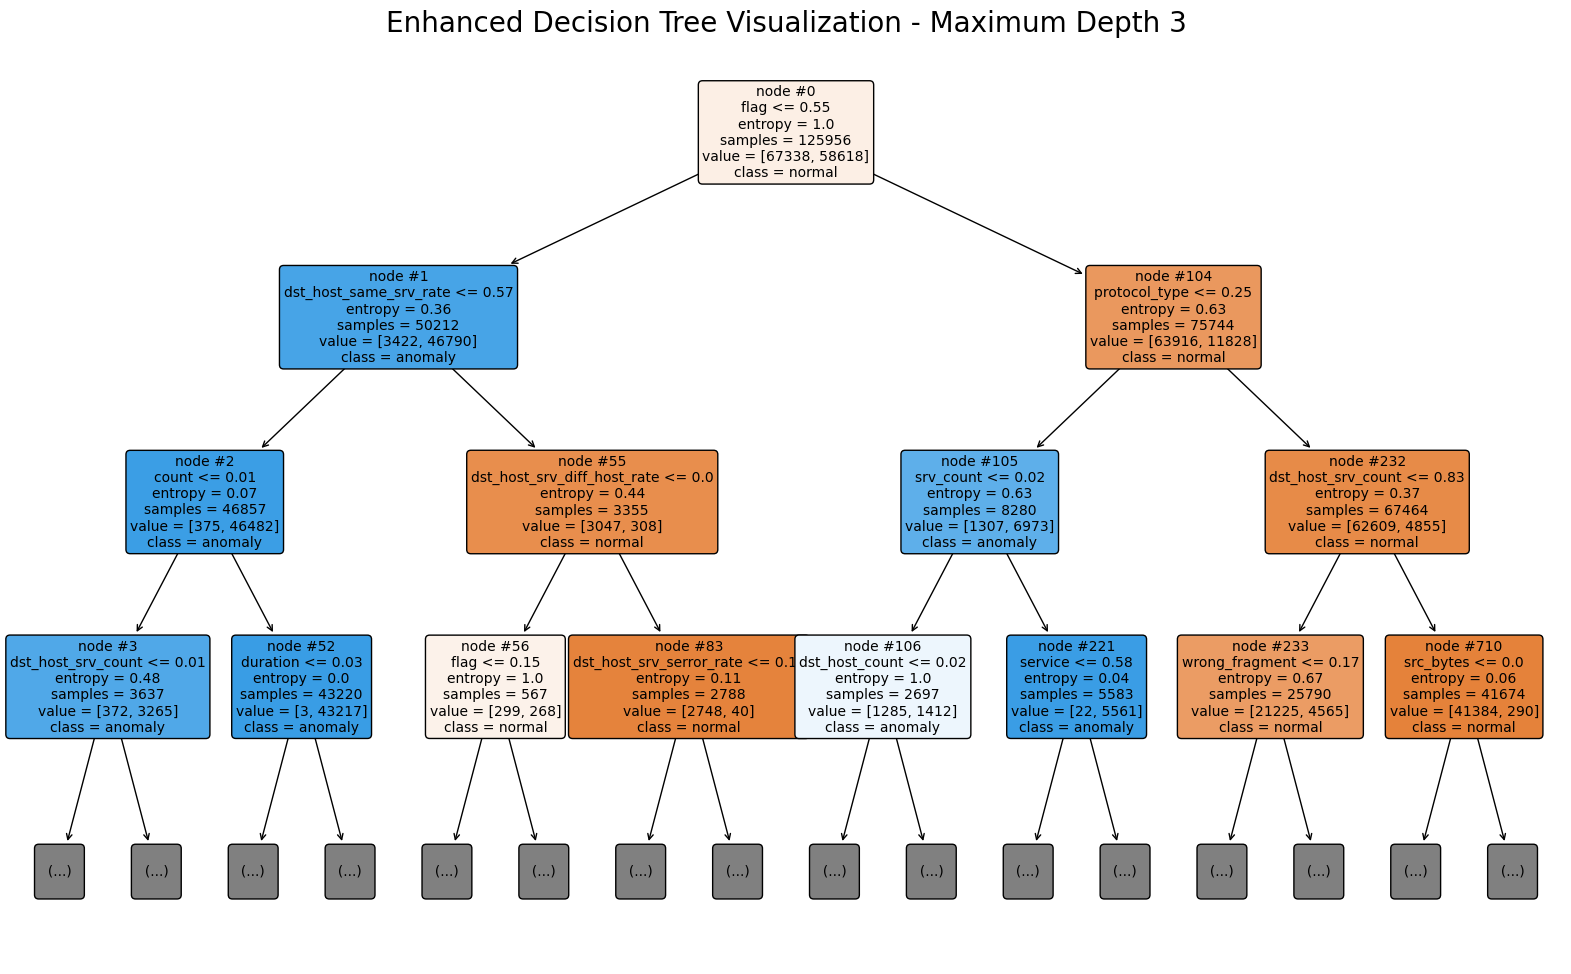

In [62]:
plt.figure(figsize=(20, 12))  # Increase the figure size for better visibility
plot_tree(clf, filled=True, feature_names=list(X_train.columns), class_names=['normal', 'anomaly'],
          rounded=True, max_depth=3, fontsize=10, node_ids=True,
          proportion=False, precision=2, label='all')

# Adding titles and labels for clarity
plt.title("Enhanced Decision Tree Visualization - Maximum Depth 3", fontsize=20)
plt.xlabel("Node ID", fontsize=16)
plt.ylabel("Depth", fontsize=16)
plt.show()




#### Feature importance :  

* Feature importance is calculated as the decrease in node impurity weighted by the probability of reaching that node. The node probability can be calculated by the number of samples that reach the node, divided by the total number of samples. The higher the value the more important the feature [20]

* In our case the highest is num_access_files:  9.102651013497055e-05

* And some with zero value of importance : urgent: 0.0, num_failed_logins: 0.0, num_outbound_cmds: 0.0 ,is_host_login: 0.0 which meas they have no informative feature or are used to split 

In [63]:
# Identify the most significant features
feature_importance = clf.feature_importances_
feature_importance_dict = dict(zip(X_train.columns, feature_importance))

# The features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

# Display the most significant features
print("\nMost Significant Features:")
for feature, importance in sorted_features:
    print(f"{feature}: {importance}")


Most Significant Features:
flag: 0.4914575798224698
protocol_type: 0.13792686267241513
dst_host_same_srv_rate: 0.11232904162554157
dst_host_srv_count: 0.05434283658945507
dst_host_same_src_port_rate: 0.023132987445661092
src_bytes: 0.021987724093182157
dst_host_count: 0.0214347397366039
srv_count: 0.019597937940294456
wrong_fragment: 0.018652643477276274
count: 0.01791323471683695
dst_host_rerror_rate: 0.015961400140736947
hot: 0.012416809017541676
service: 0.012056963799208476
dst_host_srv_diff_host_rate: 0.01151305408396928
duration: 0.009849550187527962
dst_host_diff_srv_rate: 0.006081175875304257
dst_host_serror_rate: 0.005077162401859555
dst_bytes: 0.0021798085120719973
dst_host_srv_serror_rate: 0.0013898215548319838
serror_rate: 0.0008836935845654934
rerror_rate: 0.0005841231685014028
logged_in: 0.0005486762708664432
dst_host_srv_rerror_rate: 0.0005158102644315766
same_srv_rate: 0.0004440015804806618
num_root: 0.00038286223791806804
diff_srv_rate: 0.0002807263828951309
num_file_

### 3.4 Evaluation

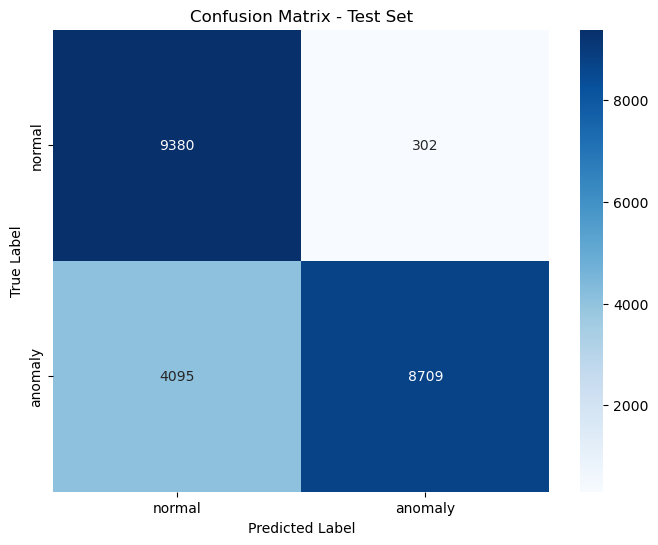


Test Set Evaluation:

Accuracy: 0.8044561060215245

Classification Report:
              precision    recall  f1-score   support

         0.0       0.70      0.97      0.81      9682
         1.0       0.97      0.68      0.80     12804

    accuracy                           0.80     22486
   macro avg       0.83      0.82      0.80     22486
weighted avg       0.85      0.80      0.80     22486



In [64]:
# Evaluate the performance on the test set
accuracy_test = accuracy_score(Y_test, Y_test_pred)
classification_rep_test = classification_report(Y_test, Y_test_pred)

# Calculate the confusion matrix
conf_matrix = confusion_matrix(Y_test, Y_test_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['normal', 'anomaly'], yticklabels=['normal', 'anomaly'])
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Display the evaluation metrics for the test set
print("\nTest Set Evaluation:")
print("\nAccuracy:", accuracy_test)
print("\nClassification Report:")
print(classification_rep_test)


* The accuracy of the model here about **0.79** which is acceptable , but there is still the number of traffic classied as normal but are not normal is most concerning part of a detection system, more important than having false Alarms.

* we can try increase the accuracy by **checking the data again** , or by changing the **depth number for instance** as shown below

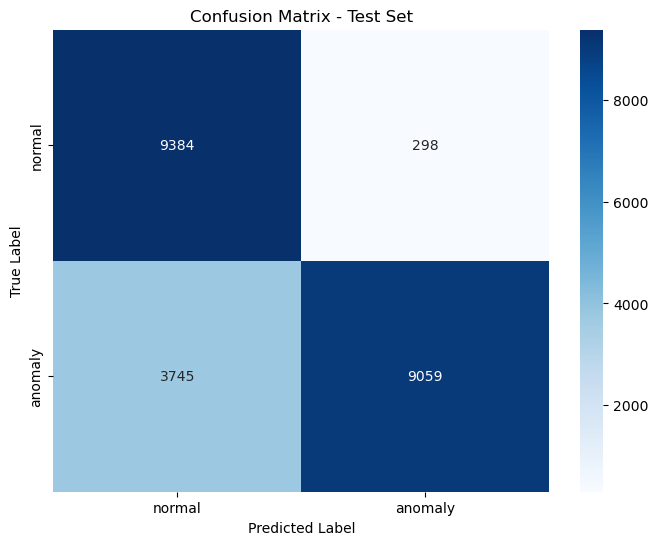


Test Set Evaluation:

Accuracy: 0.8201992350796051

Classification Report:
              precision    recall  f1-score   support

         0.0       0.71      0.97      0.82      9682
         1.0       0.97      0.71      0.82     12804

    accuracy                           0.82     22486
   macro avg       0.84      0.84      0.82     22486
weighted avg       0.86      0.82      0.82     22486



In [65]:
# Train a decision tree classifier with entropy criterion
clf2 = DecisionTreeClassifier(max_depth=15, min_samples_leaf=1, min_samples_split=2, criterion='entropy', random_state=60)
clf2.fit(X_train, Y_train)

# Predictions on the test set
Y_test_pred = clf2.predict(X_test)


# Evaluate the performance on the test set
accuracy_test = accuracy_score(Y_test, Y_test_pred)
classification_rep_test = classification_report(Y_test, Y_test_pred)

# Calculate the confusion matrix
conf_matrix = confusion_matrix(Y_test, Y_test_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['normal', 'anomaly'], yticklabels=['normal', 'anomaly'])
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Display the evaluation metrics for the test set
print("\nTest Set Evaluation:")
print("\nAccuracy:", accuracy_test)
print("\nClassification Report:")
print(classification_rep_test)


##### After changing the depth to 15 now the accuracy is better with more than 0.80 with less ignored abnormal behavior 

### Correct predictions distributed across the difficulty levels : 

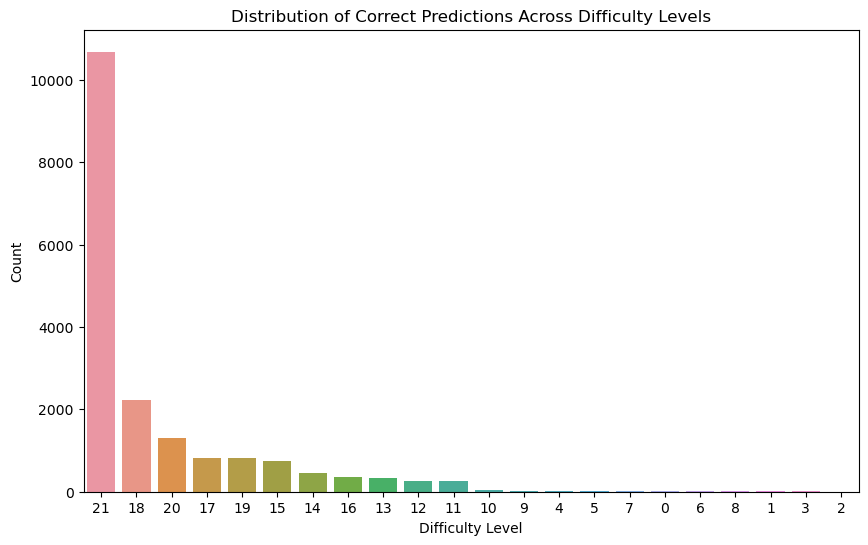

Descriptive Statistics for Correct Predictions:
count    18443.000000
mean        19.225018
std          2.840901
min          0.000000
25%         18.000000
50%         21.000000
75%         21.000000
max         21.000000
Name: difficulty_level, dtype: float64


In [66]:
# Get indices of correct predictions
correct_predictions = Y_test == Y_test_pred

# Reset index of df_test_dup
df_test_dup_reset = df_test_dup.reset_index(drop=True)

# Extract difficulty levels for correct predictions
correct_difficulty_levels = df_test_dup_reset.loc[correct_predictions, 'difficulty_level']

# Descriptive Statistics
statistics = correct_difficulty_levels.describe()

# Visualization
plt.figure(figsize=(10, 6))
sns.countplot(x=correct_difficulty_levels, order=correct_difficulty_levels.value_counts().index)
plt.title("Distribution of Correct Predictions Across Difficulty Levels")
plt.xlabel("Difficulty Level")
plt.ylabel("Count")
plt.show()

# Display Descriptive Statistics
print("Descriptive Statistics for Correct Predictions:")
print(statistics)


#### _As shown above, most of the correct prediction are on the side of where the distribution of the difficulty level lays on both datasets_ 

## 4. Something else of your own! : 

#### Grid search to  find the right paramater to tune the machine learning model :

In [67]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

# Create the base model
dt = DecisionTreeClassifier(random_state=42)

# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

# Fit the grid search to the data
grid_search.fit(X_train, Y_train)

# Print the best parameters and the best model
print("Best parameters found: ", grid_search.best_params_)
best_model = grid_search.best_estimator_



Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters found:  {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}


* It suggested that we should use this paramaters **{'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}**

#### Doing the learning again :  

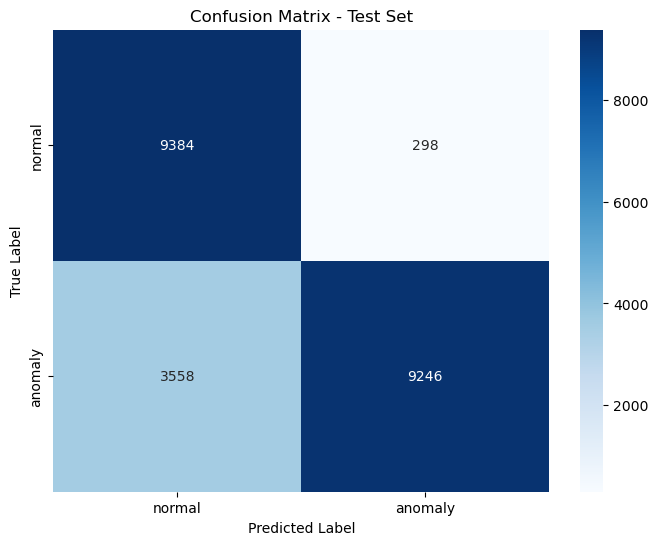


Test Set Evaluation:

Accuracy: 0.8285155207684781

Classification Report:
              precision    recall  f1-score   support

         0.0       0.73      0.97      0.83      9682
         1.0       0.97      0.72      0.83     12804

    accuracy                           0.83     22486
   macro avg       0.85      0.85      0.83     22486
weighted avg       0.86      0.83      0.83     22486



In [68]:
# Train a decision tree classifier with entropy criterion
clf2 = DecisionTreeClassifier(max_depth=20, min_samples_leaf=1, min_samples_split=2, criterion='entropy', random_state=60)
clf2.fit(X_train, Y_train)

# Predictions on the test set
Y_test_pred = clf2.predict(X_test)


# Evaluate the performance on the test set
accuracy_test = accuracy_score(Y_test, Y_test_pred)
classification_rep_test = classification_report(Y_test, Y_test_pred)

# Calculate the confusion matrix
conf_matrix = confusion_matrix(Y_test, Y_test_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['normal', 'anomaly'], yticklabels=['normal', 'anomaly'])
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Display the evaluation metrics for the test set
print("\nTest Set Evaluation:")
print("\nAccuracy:", accuracy_test)
print("\nClassification Report:")
print(classification_rep_test)


### *After changing the accuracy changed to more than 0.81 and the skipped anomalies are now are less than other two trained models before* 

## Cross-Validation Technique to evaluate and find the right paramaters : 

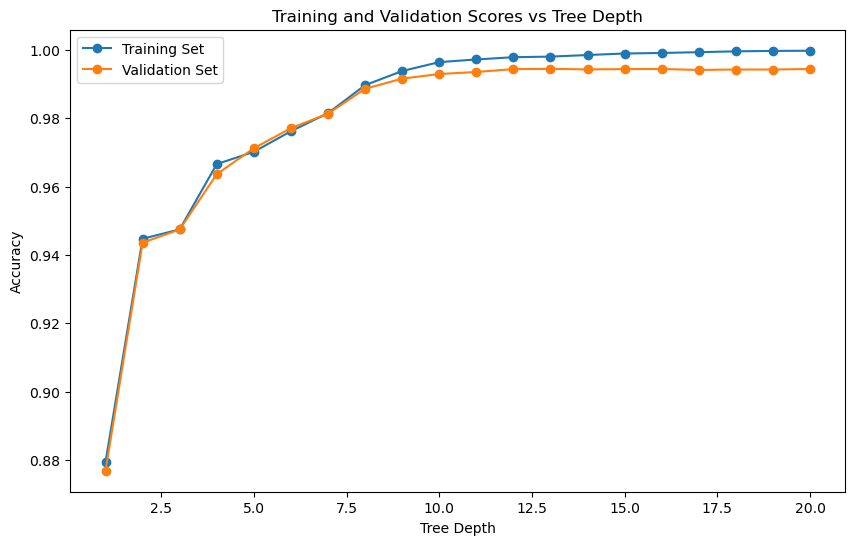


Test Set Evaluation:

Accuracy: 0.8214444543271369

Classification Report:
              precision    recall  f1-score   support

         0.0       0.71      0.97      0.82      9682
         1.0       0.97      0.71      0.82     12804

    accuracy                           0.82     22486
   macro avg       0.84      0.84      0.82     22486
weighted avg       0.86      0.82      0.82     22486



In [69]:
# NOTE: This cell splits the existing X_train further into train/validation subsets
# to plot the learning curve across tree depths (depths 1-20).
# X_train and Y_train are reassigned here to 80% of their previous size.
# All subsequent model evaluations use this reduced training set.

from sklearn.model_selection import cross_val_score, train_test_split

# Split the data into training and validation sets
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.2, random_state=42)

# Define the range of tree depths to explore
depths = range(1, 21)

# Initialize lists to store training and validation scores
train_scores = []
val_scores = []

# Loop over different depths
for depth in depths:
    # Train a decision tree classifier with entropy criterion
    clf = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=1, min_samples_split=2, criterion='entropy', random_state=60)
    
    # Train the model on the training set
    clf.fit(X_train, Y_train)
    
    # Predictions on the training set
    Y_train_pred = clf.predict(X_train)
    
    # Calculate and store the training accuracy
    train_accuracy = accuracy_score(Y_train, Y_train_pred)
    train_scores.append(train_accuracy)
    
    # Perform cross-validation and store the validation accuracy
    val_accuracy = np.mean(cross_val_score(clf, X_val, Y_val, cv=5, scoring='accuracy'))
    val_scores.append(val_accuracy)

# Plot the training and validation scores
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, label='Training Set', marker='o')
plt.plot(depths, val_scores, label='Validation Set', marker='o')
plt.title('Training and Validation Scores vs Tree Depth')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Choose the best depth based on validation set performance
best_depth = depths[np.argmax(val_scores)]

# Train the model on the entire training set with the best depth
final_clf = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=1, min_samples_split=2, criterion='entropy', random_state=60)
final_clf.fit(X_train, Y_train)

# Predictions on the test set
Y_test_pred = final_clf.predict(X_test)

# Evaluate the performance on the test set
accuracy_test = accuracy_score(Y_test, Y_test_pred)
classification_rep_test = classification_report(Y_test, Y_test_pred)


# Display the evaluation metrics for the test set
print("\nTest Set Evaluation:")
print("\nAccuracy:", accuracy_test)
print("\nClassification Report:")
print(classification_rep_test)


### *The line graph displays the number of tree depth used at each iteration and comparing it with accuracy at that depth , which the best depth in this case is 20 , which what the Gridsearch technique suggested too , but not with a better accuracy*

**Neural Networks :  MLPClassifier**

* MLPClassifier stands for Multi-Layer Perceptron Classifier, It is a type of artificial neural network model used for classification tasks , and is the most fundamental type of neural network architecture when compared to other major types such as Convolutional Neural Network (CNN), Recurrent Neural Network (RNN), Autoencoder (AE) and Generative Adversarial Network (GAN)[22]

In [70]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Initialize the MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', 
                    max_iter=1000, random_state=42)

# Train the model
mlp.fit(X_train, Y_train)


# Evaluate the model
print("Training accuracy:", mlp.score(X_train, Y_train))
print("Test accuracy:", mlp.score(X_test, Y_test))

Training accuracy: 0.9970723671152396
Test accuracy: 0.806768656052655


#### *Using MLPClassifier we are able to get better results in terms of accuracy as shown above* , Gridsearch techniques could be used here too.

In [ ]:
iris = load_iris()
X_iris_train, X_iris_test, Y_iris_train, Y_iris_test = train_test_split(
    iris.data, iris.target, random_state=42)

# Define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'sgd'],
    'max_iter': [500, 750, 1000],
}

# Create the MLPClassifier
mlp_iris = MLPClassifier(random_state=42)

# Create GridSearchCV object
grid_search_iris = GridSearchCV(mlp_iris, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Fit the model on Iris data only — separate from NSL-KDD variables
grid_search_iris.fit(X_iris_train, Y_iris_train)

# Print the best parameters and corresponding accuracy
print('Best Parameters: ', grid_search_iris.best_params_)
print('Training accuracy with best parameters: ', grid_search_iris.best_score_)

# Evaluate the model on the Iris test set
iris_test_accuracy = grid_search_iris.score(X_iris_test, Y_iris_test)
print('Iris Test accuracy with best parameters: ', iris_test_accuracy)

### GridSearchCV on MLPClassifier — Iris Dataset (Demonstration)

> **Note:** The cells above demonstrate GridSearchCV with MLPClassifier using the Iris dataset as a simple, fast example. All variables are scoped separately (`X_iris_train`, `X_iris_test`, etc.) and do not affect the NSL-KDD data. For MLP results on NSL-KDD, see Cell 186 (80.5% test accuracy).  
> Applying GridSearchCV to the MLP on NSL-KDD is left as future work due to compute constraints — the full parameter grid would require several hours on CPU.

In [ ]:
# Initialize the MLPClassifier with best parameters found above
mlp_iris_best = MLPClassifier(hidden_layer_sizes=(50,), activation='relu', solver='adam',
                               max_iter=1000)

# Train on Iris data only
mlp_iris_best.fit(X_iris_train, Y_iris_train)

# Evaluate on Iris test set
print('Iris Training accuracy:', mlp_iris_best.score(X_iris_train, Y_iris_train))
print('Iris Test accuracy:', mlp_iris_best.score(X_iris_test, Y_iris_test))

### Note on Iris Test Accuracy

A test accuracy of 1.0 on the Iris dataset with a small, well-separated dataset and a simple MLP is plausible, but may also indicate overfitting for this particular train/test split. Cross-validation on Iris (not shown here) would confirm generalisation. This result is specific to the Iris dataset and is not representative of the NSL-KDD IDS model performance.

## 5. Conclusions

* The NSL-KDD dataset is a simulation of certain types of attacks such as DoS, U2R, R2L and probing attacks. It was generated to help improve the performance and evaluation of anomaly detection models. However, the dataset has characteristics that limit real-world applicability: it originates from 1999 network traffic, does not cover modern attack vectors, and the test set contains attack types absent from the training set — a challenge that any deployed IDS must address.

* The analysis demonstrates that a tuned decision tree (depth=20, entropy criterion) achieves approximately 82% accuracy on the NSL-KDD test set, with flag and protocol_type as the most informative features. The MLP neural network achieves comparable accuracy (~80%) with significantly higher training accuracy, suggesting some degree of overfitting that cross-validation would help quantify.

* Future work should consider: one-hot encoding for categorical features, SMOTE oversampling to address class imbalance, Random Forest or gradient boosting as comparison models, and evaluation on more recent datasets such as UNSW-NB15 or CIC-IDS-2017 to assess generalisation to contemporary attack patterns.

## References

[1] NSL-KDD Dataset, Canadian Institute of Cybersecurity, University of New Brunswick, https://www.unb.ca/cic/datasets/nsl.html . Accessed 16th September 2023.

[2] M. Tavallaee, E. Bagheri, W. Lu and A. A. Ghorbani, "A detailed analysis of the KDD CUP 99 data set," 2009 IEEE Symposium on Computational Intelligence for Security and Defense Applications, Ottawa, ON, Canada, 2009, pp. 1-6, doi: 10.1109/CISDA.2009.5356528.

[3] J. McHugh, "Testing intrusion detection systems: a critique of the 1998 and 1999 DARPA  intrusion detection system evaluations as performed by Lincoln Laboratory", ACM Transactions on Information and System Security, vol. 3, no. 4, pp. 262-294, 2000.

[4] [Scikit-learn: Machine Learning in Python](https://jmlr.csail.mit.edu/papers/volume12/pedregosa11a/pedregosa11a.pdf), Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.

[5] What is an intrusion detection system (IDS)?, IBM https://www.ibm.com/topics/intrusion-detection-system  Accessed 09th December 2023.

[6] What Is Security Analytics?, trekki, https://www.trellix.com/security-awareness/operations/what-is-security-analytics/ Accessed 10th December 2023.

[7] KDD Cup 1999 Data https://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html  Accessed 10th December 2023.

[8] Splitting a Dataset into Train and Test Sets, baeldung, https://www.baeldung.com/cs/train-test-datasets-ratio Accessed 11th December 2023.

[9] CS250: Python for Data Science, saylor,  https://learn.saylor.org/mod/book/view.php?id=55290&chapterid=40869 Accessed 11th December 2023.

[10] How to Check for Duplicate Values in Pandas DataFrame Column, SaturnCloud,  https://saturncloud.io/blog/how-to-check-for-duplicate-values-in-pandas-dataframe-column Accessed 11th December 2023.

[11] How to Split a Dataset Into Training and Testing Sets with Python, towardsdatascience, https://towardsdatascience.com/how-to-split-a-dataset-into-training-and-testing-sets-b146b1649830  Accessed 11th December 2023.

[12] Overfitting and Underfitting With Machine Learning Algorithms , machinelearningmastery , https://machinelearningmastery.com/overfitting-and-underfitting-with-machine-learning-algorithms/  Accessed 11th December 2023.

[13] 6 ways to reduce different types of bias in machine learning, techtarget,  https://www.techtarget.com/searchenterpriseai/feature/6-ways-to-reduce-different-types-of-bias-in-machine-learning Accessed 12th December 2023.

[14] Categorical Variables for Machine Learning Algorithms, towardsdatascience, https://towardsdatascience.com/categorical-variables-for-machine-learning-algorithms-d2768d587ab6. Accessed 12th December 2023.

[15] How to Perform Label Encoding in Python?, analyticsvidhya, https://www.analyticsvidhya.com/blog/2023/07/label-encoding-in-python/. Accessed 13th December 2023.

[16] The min-max scaling method , oreilly,  https://www.oreilly.com/library/view/feature-engineering-made/9781787287600/aa5580ee-6fb7-4ac2-a1fe-369d95b70168.xhtml. Accessed 13th December 2023.

[17] When to perform a Feature Scaling?, atoti,https://www.atoti.io/articles/when-to-perform-a-feature-scaling/. Accessed 13th December 2023.

[18] What is a Decision Tree?, IBM, https://www.ibm.com/topics/decision-trees Accessed 13th December 2023.

[19] Decision Tree Classification in Python Tutorial, DataCamp, https://www.datacamp.com/tutorial/decision-tree-classification-python Accessed 13th December 2023.

[20] The Mathematics of Decision Trees, towardsdatascience,  https://towardsdatascience.com/the-mathematics-of-decision-trees-random-forest-and-feature-importance-in-scikit-learn-and-spark-f2861df67e3 Accessed 14th December 2023.

[21] Intrusion Detection, OWASP, https://owasp.org/www-community/controls/Intrusion_Detection Accessed 14th December 2023.

[22] Creating a Multilayer Perceptron (MLP) Classifier Model to Identify Handwritten Digits , towardsdatascience, https://towardsdatascience.com/creating-a-multilayer-perceptron-mlp-classifier-model-to-identify-handwritten-digits-9bac1b16fe10 Accessed 14th December 2023.

